In [1]:
name = "openChain50_dl0_25"

In [2]:
import sqlite3
import pandas as pd
import numpy as np
np.set_printoptions(suppress=True)
import os
from IPython.display import display_markdown as md
import matplotlib.pyplot as plt
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

DB_FILE = name+".db"
DB_FILE_ro = name+".db"

In [4]:
conn = sqlite3.connect(DB_FILE_ro)
query_metadata = """
SELECT id, startDate, completionDate, computerName, size, rs, eta, prefactors, T_bot, T_top, temperature_description, number_of_rounds, allgather_time 
FROM _experiments 
ORDER BY startDate DESC 
LIMIT 1
"""
df_exp = pd.read_sql_query(query_metadata, conn)
experimentID = int(df_exp['id'].iloc[0])#df_exp is one row so iloc[0], for last row of query df_exp use iloc[-1]
size = df_exp['size'].iloc[0]
overlapRatio = df_exp['rs'].iloc[0]
eta = df_exp['eta'].iloc[0]
prefactors = list(map(float,df_exp['prefactors'].iloc[0][1:-1:].split(',')))
T_bot = df_exp['T_bot'].iloc[0]
T_top = df_exp['T_top'].iloc[0]
temperature_description = df_exp['temperature_description'].iloc[0]
number_of_rounds = df_exp['number_of_rounds'].iloc[0]
seconds_between_rounds = df_exp['allgather_time'].iloc[0]
startDate = df_exp['startDate'].iloc[0]
completionDate = df_exp['completionDate'].iloc[0]
if temperature_description =='linear':
    temperature_description_string = ' wrong notebook!'
elif temperature_description =='geometric':
    temperature_description_string = ' wrong notebook!'
else:
    temperature_description_string = ' temperature intervals discretised into '+str(number_of_rounds//2)+' bins, all parallel systems anneal at the same fixed temperature, temperature intervals traversed from low to high then back to low'

#initial Config data ---> taken from first frame of rank 0
cur = conn.cursor()
cur.execute("""SELECT * FROM _experiments_all_curves WHERE experimentID = ? AND frameNumber = 1 AND rankNumber = 0 """, (experimentID,))
row = cur.fetchone()
edgeLength = row[8]
curveLength =  row[7]
sphereCount = row[9]
reachConstraint = row[10]
cur.execute("""SELECT inputSphereRadius FROM _measures WHERE curveID = ?""", (row[0], ))
inputSphereRadius = cur.fetchone()[0]


MARKDOWN='''## Experimenting with '''+name+''' experiment id $='''+str(experimentID)+'''$

- $r_{s} = '''+str(overlapRatio)+'''$, and  $\\eta ='''+str(eta)+'''$ with input sphere $R(1 + r_{s}^{*}) = '''+str(inputSphereRadius)+'''$, and embedded tube radius $'''+str(reachConstraint)+'''$ the curve is interpolated with '''+str(sphereCount)+''' balls with (fixed) approximate edge length $dl='''+str(edgeLength)+'''$.

- Coefficients are $\\alpha_{0} = '''+str(prefactors[0])+'''$, $\\alpha_{1} = '''+str(prefactors[1])+'''$, $\\alpha_{2} = '''+str(prefactors[2])+'''$, $\\alpha_{3} = '''+str(prefactors[3])+'''$

- Computing over '''+str(size)+''' systems  with temperature $T\in['''+str(T_bot)+''','''+str(T_top)+''']$, '''+temperature_description_string+'''.

- Each round lasting '''+str(seconds_between_rounds)+''' seconds for '''+str(number_of_rounds)+''' rounds.

- Experiment computed for '''+str(round((number_of_rounds*seconds_between_rounds)/(60*60*24), 3))+''' days.'''
md(MARKDOWN, raw=True)

## Experimenting with openChain50_dl0_25 experiment id $=1$

- $r_{s} = 0.1$, and  $\eta =0.05$ with input sphere $R(1 + r_{s}^{*}) = 1.10856$, and embedded tube radius $201$ the curve is interpolated with 0.25001 balls with (fixed) approximate edge length $dl=50.001$.

- Coefficients are $\alpha_{0} = 59.95606$, $\alpha_{1} = -0.45881$, $\alpha_{2} = 0.00595$, $\alpha_{3} = 0.0007$

- Computing over 6 systems  with temperature $T\in[0.0005,5.0]$,  temperature intervals discretised into 20 bins, all parallel systems anneal at the same fixed temperature, temperature intervals traversed from low to high then back to low.

- Each round lasting 10000.0 seconds for 40 rounds.

- Experiment computed for 4.63 days.

In [5]:
from datetime import datetime

def parse_time(s):
    return datetime.strptime(s, '%d/%m/%Y/%H/%M/%S').timestamp()

start_time_seconds = parse_time(startDate)

In [6]:
#normalised_energy = float(line[18]) # (E - E_0)/L
def compute_normalised_energy(V, A, C, X, V_0, A_0, C_0, X_0, L):
    return (prefactors[0]*(V - V_0) + prefactors[1]*(A - A_0) + prefactors[2]*(C - C_0) + prefactors[3]*(X - X_0))/L
        

In [7]:
query_curves = f"""
SELECT id, frameNumber, rankNumber, temperature, energy, time_in_sequence
FROM _experiments_all_curves 
WHERE experimentID = {experimentID}
ORDER BY rankNumber, frameNumber
"""
df_curves = pd.read_sql_query(query_curves, conn)
curve_ids_str = ",".join(map(str, df_curves['id'].unique()))

query_measures = f"""
SELECT * FROM _measures 
WHERE curveID IN ({curve_ids_str})
"""
df_measures = pd.read_sql_query(query_measures, conn)

query_experimet_stats_intra_rounds = f"""
SELECT * FROM _experiment_stats_intra_rounds
WHERE curveID IN ({curve_ids_str})
"""
df_exp_stats_intra_rounds = pd.read_sql_query(query_experimet_stats_intra_rounds, conn)    

In [8]:
df_exp_stats_intra_rounds.head()

,id,curveID,rank,it_no,T,prob,deltaE,accept,energy,bin_index,time,round_nbr,it_no_intra_round
0,1,1,0,0,0.0005,1.000,0.00000,1,0.000000,0,0.000286,0,0
1,2,2,0,1023,0.0005,1.003,0.00000,0,-0.000179,0,51.069722,0,1023
2,3,3,0,3144,0.0005,2.698,-0.00050,0,-0.000318,0,165.430666,0,3144
3,4,4,0,5298,0.0005,0.500,0.00035,0,-0.000587,0,286.144075,0,5298
4,5,5,0,6388,0.0005,0.001,0.00338,0,-0.000638,0,344.348598,0,6388


In [9]:
df_curves.head()

,id,frameNumber,rankNumber,temperature,energy,time_in_sequence
0,1,1,0,0.0005,0.000000,0.000286
1,2,1,0,0.0005,-0.000179,51.069722
2,3,2,0,0.0005,-0.000318,165.430666
3,4,3,0,0.0005,-0.000587,286.144075
4,5,4,0,0.0005,-0.000638,344.348598


In [10]:
print(df_curves['temperature'].unique())

[0.0005   0.000812 0.001318 0.002141 0.003476 0.005644 0.009165 0.014882
 0.024165 0.039238 0.063714 0.103457 0.167991 0.27278  0.442933 0.719225
 1.167861 1.896345 5.       3.079241]


In [11]:
df_exp_stats_intra_rounds[:5:]

,id,curveID,rank,it_no,T,prob,deltaE,accept,energy,bin_index,time,round_nbr,it_no_intra_round
0,1,1,0,0,0.0005,1.000,0.00000,1,0.000000,0,0.000286,0,0
1,2,2,0,1023,0.0005,1.003,0.00000,0,-0.000179,0,51.069722,0,1023
2,3,3,0,3144,0.0005,2.698,-0.00050,0,-0.000318,0,165.430666,0,3144
3,4,4,0,5298,0.0005,0.500,0.00035,0,-0.000587,0,286.144075,0,5298
4,5,5,0,6388,0.0005,0.001,0.00338,0,-0.000638,0,344.348598,0,6388


In [12]:
energy_increasing = df_exp_stats_intra_rounds[df_exp_stats_intra_rounds['deltaE'] > 0]

In [13]:
dragfactor = int(energy_increasing.groupby(['rank', 'round_nbr']).size().median() / 2)
print(f"Suggested drag factor: {dragfactor}")
energy_increasing = energy_increasing.sort_values(['rank', 'round_nbr', 'it_no_intra_round']) #sorts by rank and then it_no

# groupby('rank') splits the dataframe into groups, one per rank
# .apply(func) then applies func to each group independently
# rolling(window=3000) is a built-in pandas method
# for each row it looks back at the previous 3000 rows and computes the mean
# min_periods=1 means if there are fewer than 3000 rows available
# (e.g. at the start) it averages over however many are available

energy_increasing['exp(P)'] = energy_increasing.groupby(['rank', 'round_nbr'])['prob'].transform(
    lambda x: x.rolling(window=dragfactor, min_periods=1).mean()
)
energy_increasing['exp(delE)'] = energy_increasing.groupby(['rank', 'round_nbr'])['deltaE'].transform(
    lambda x: x.rolling(window=dragfactor, min_periods=1).mean()
)

Suggested drag factor: 18


In [14]:
energy_increasing.head()

,id,curveID,rank,it_no,T,prob,deltaE,accept,energy,bin_index,time,round_nbr,it_no_intra_round,exp(P),exp(delE)
3,4,4,0,5298,0.0005,0.500,0.00035,0,-0.000587,0,286.144075,0,5298,0.5000,0.000350
4,5,5,0,6388,0.0005,0.001,0.00338,0,-0.000638,0,344.348598,0,6388,0.2505,0.001865
5,6,6,0,7471,0.0005,0.210,0.00078,0,-0.000564,0,399.297692,0,7471,0.2370,0.001503
7,8,8,0,9619,0.0005,0.187,0.00084,0,-0.000832,0,519.327025,0,9619,0.2245,0.001338
8,9,9,0,10695,0.0005,0.699,0.00018,0,-0.000888,0,582.861015,0,10695,0.3194,0.001106


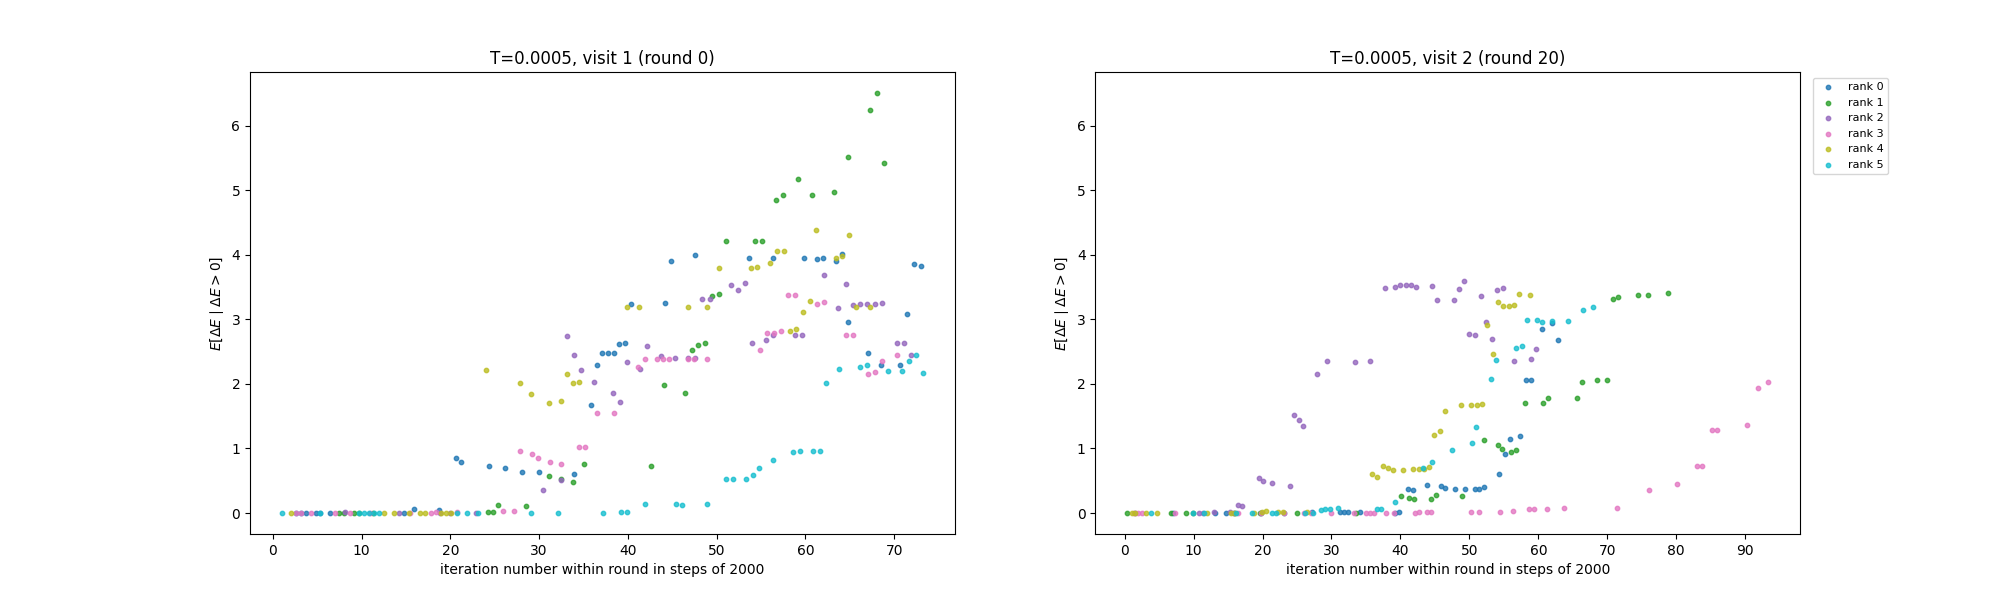

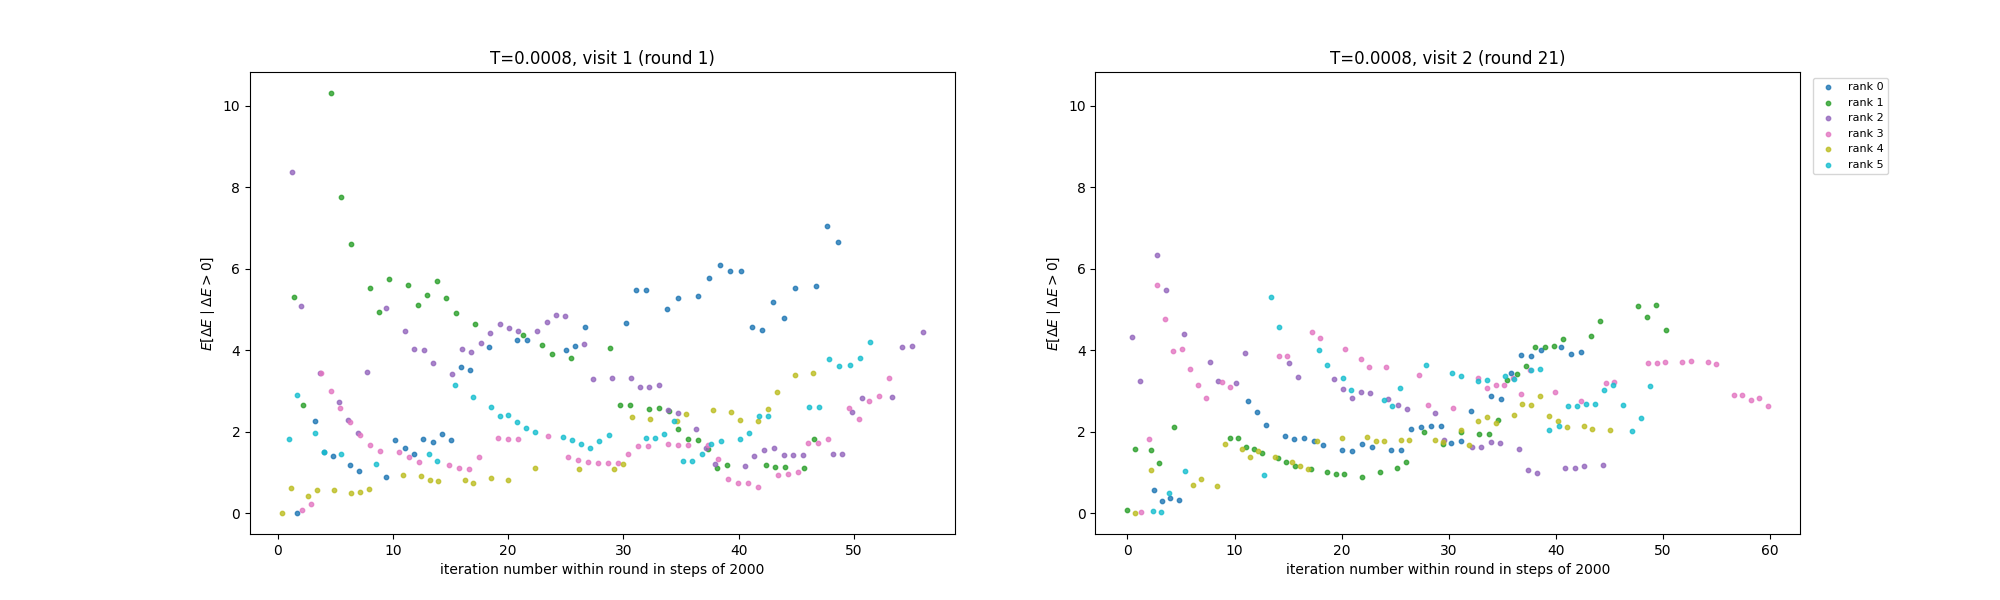

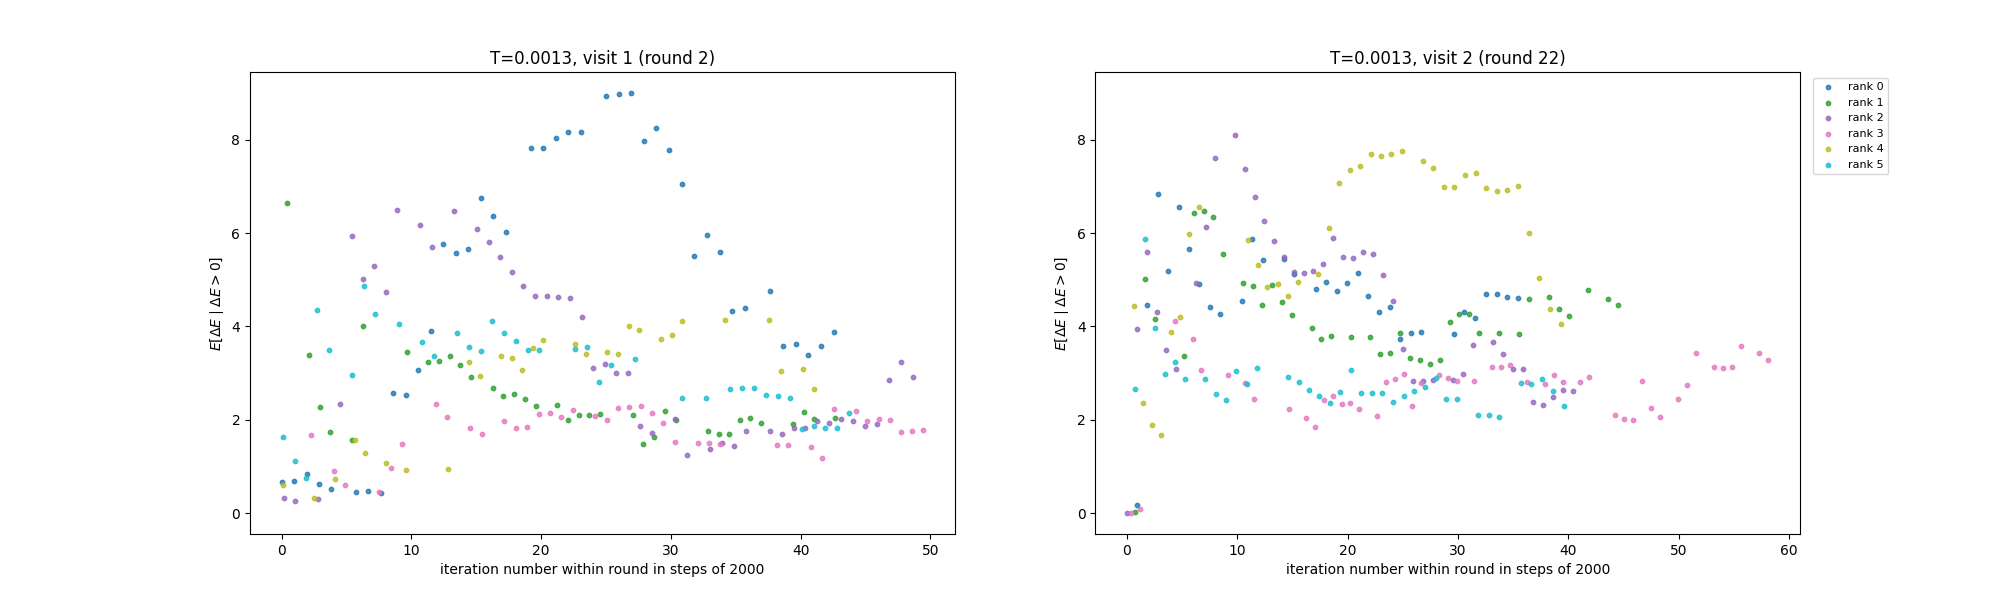

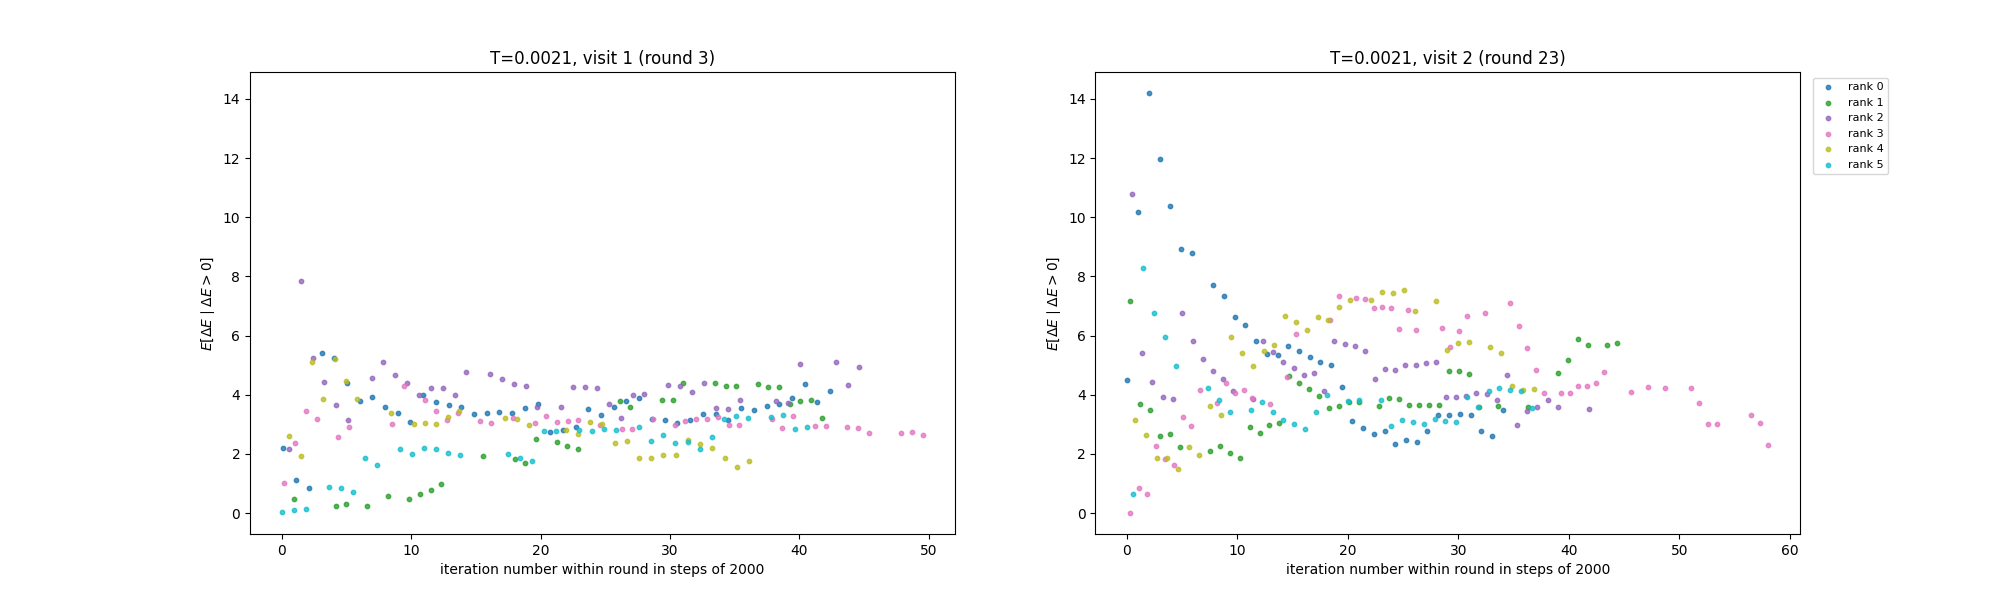

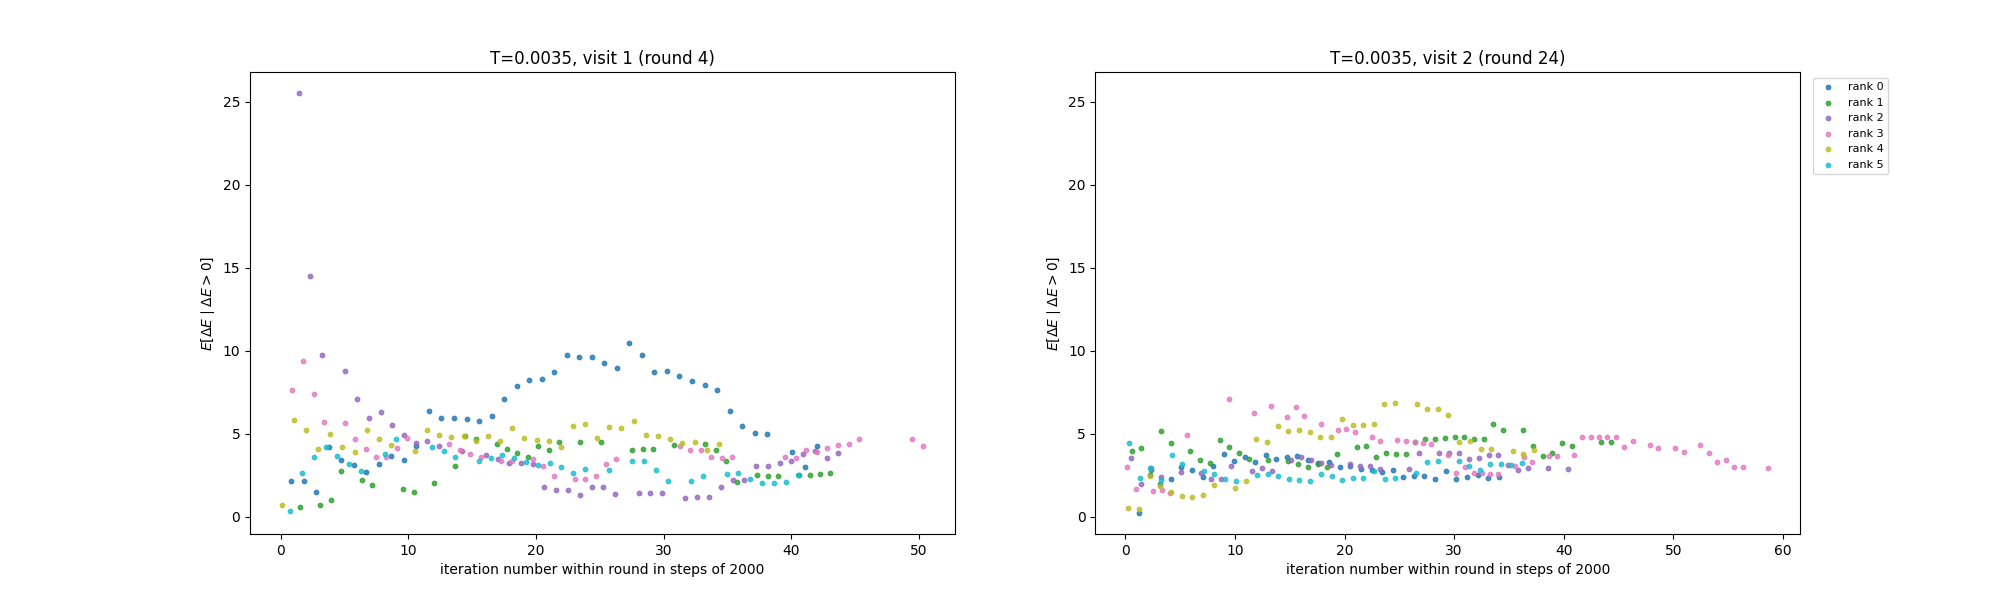

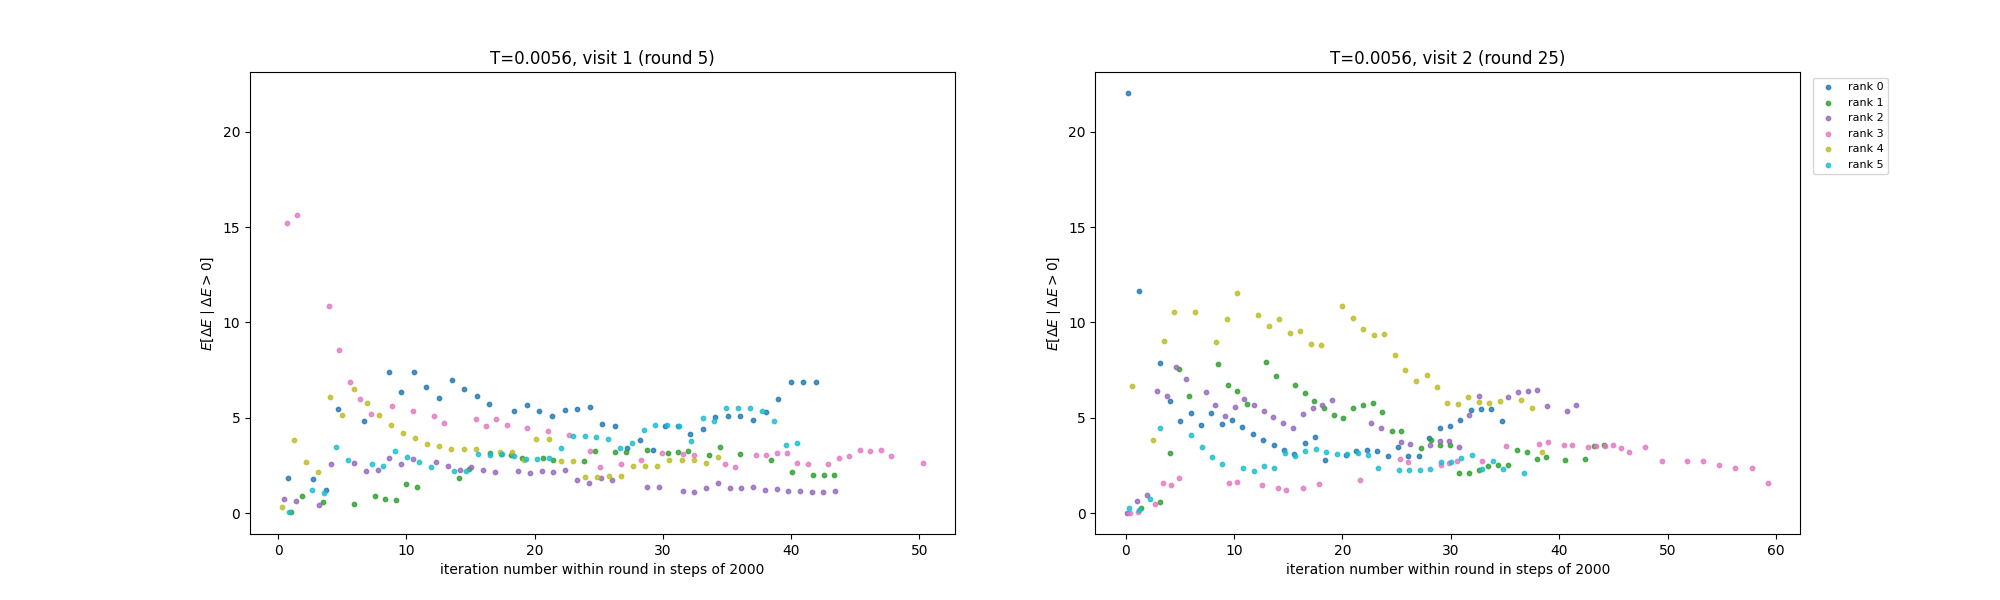

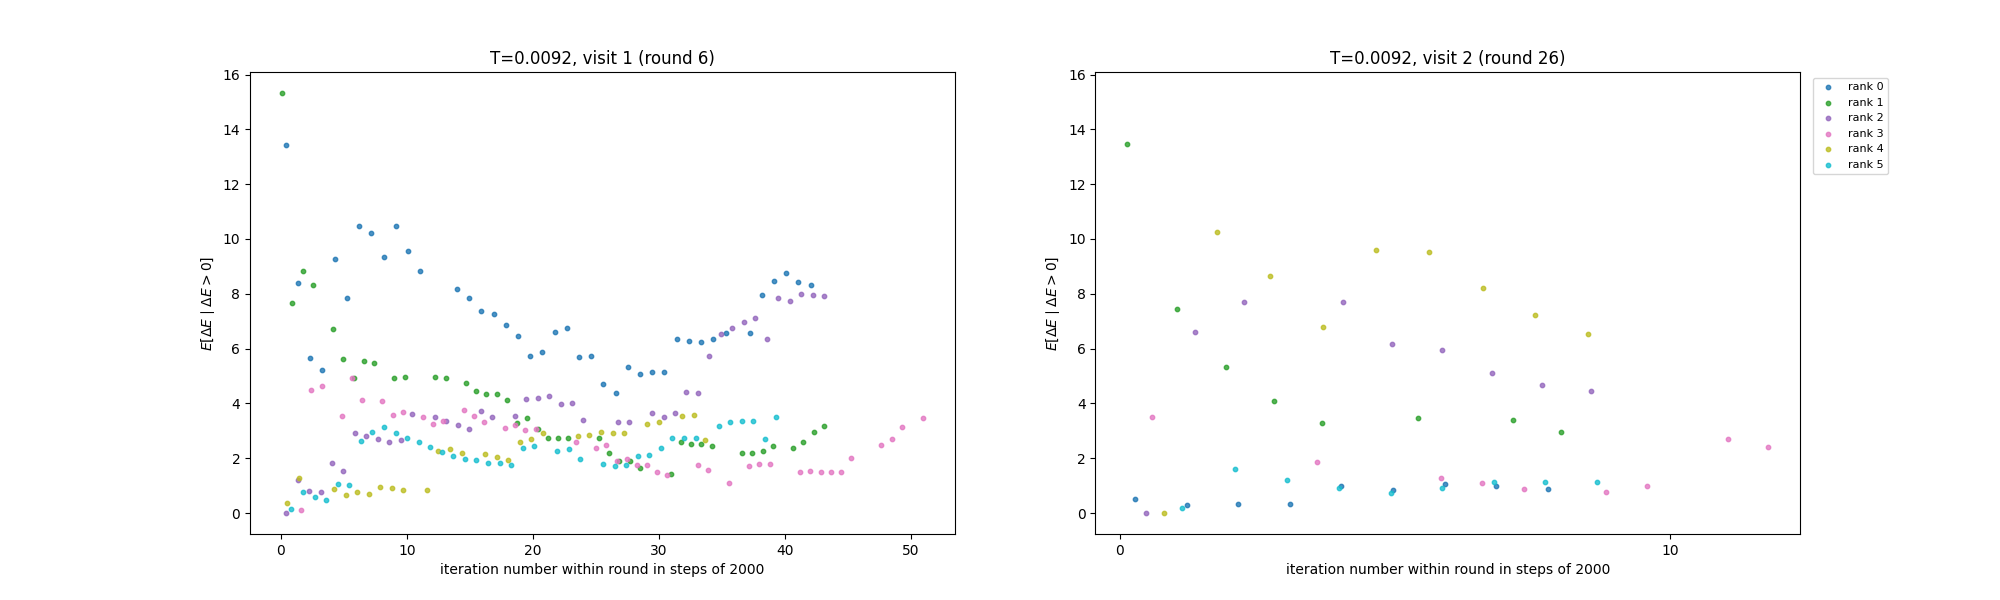

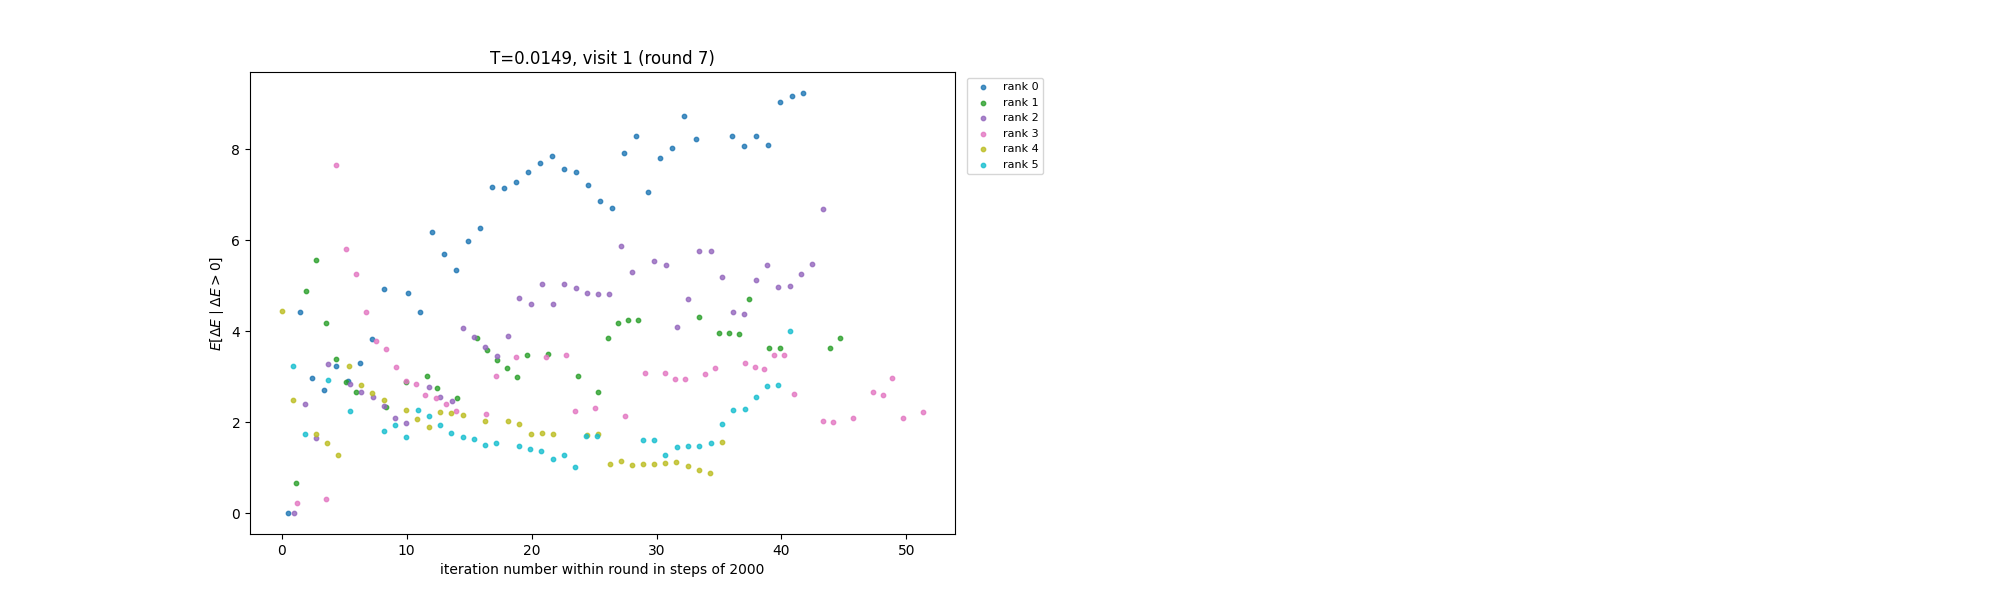

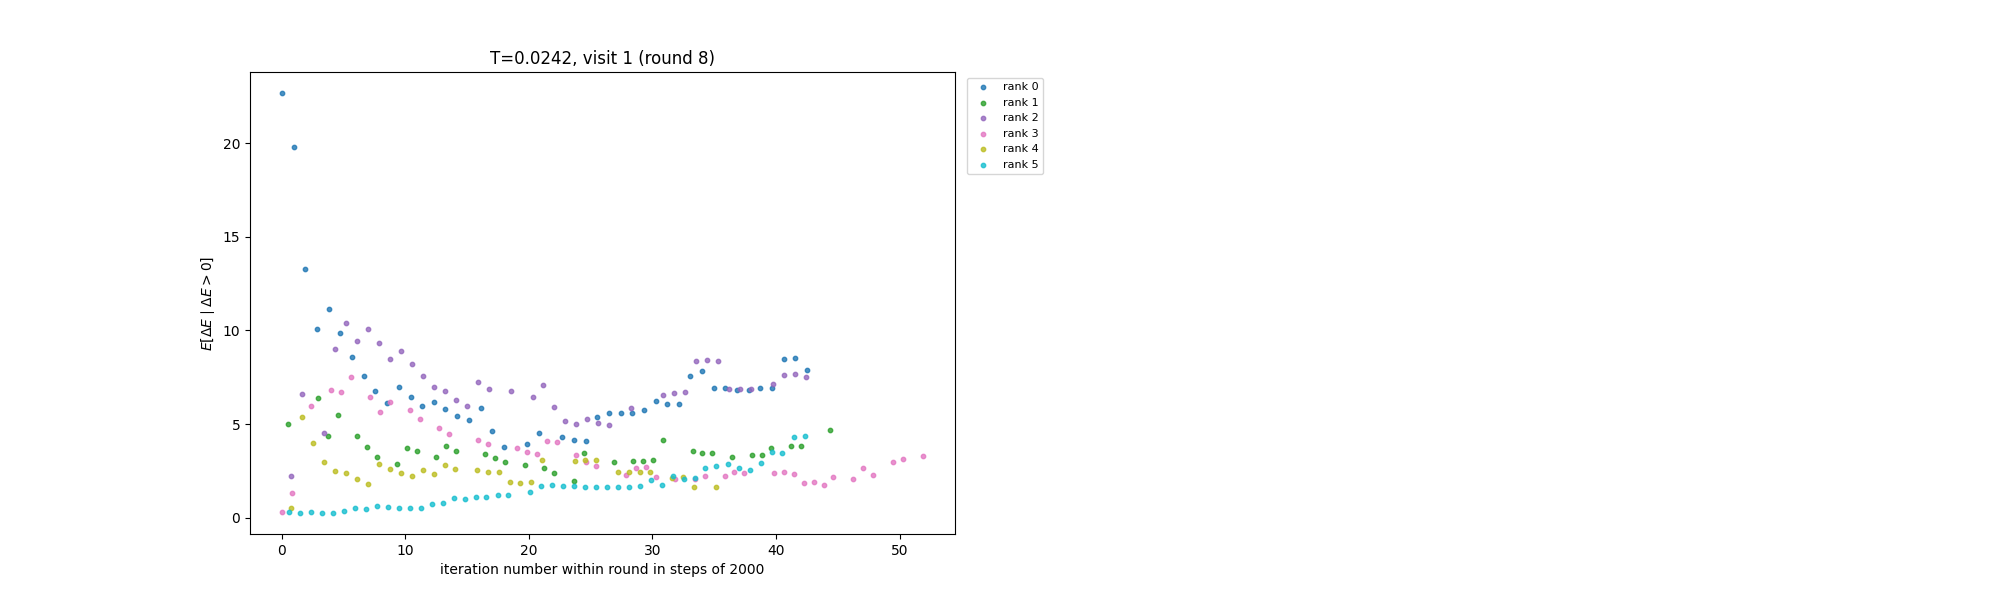

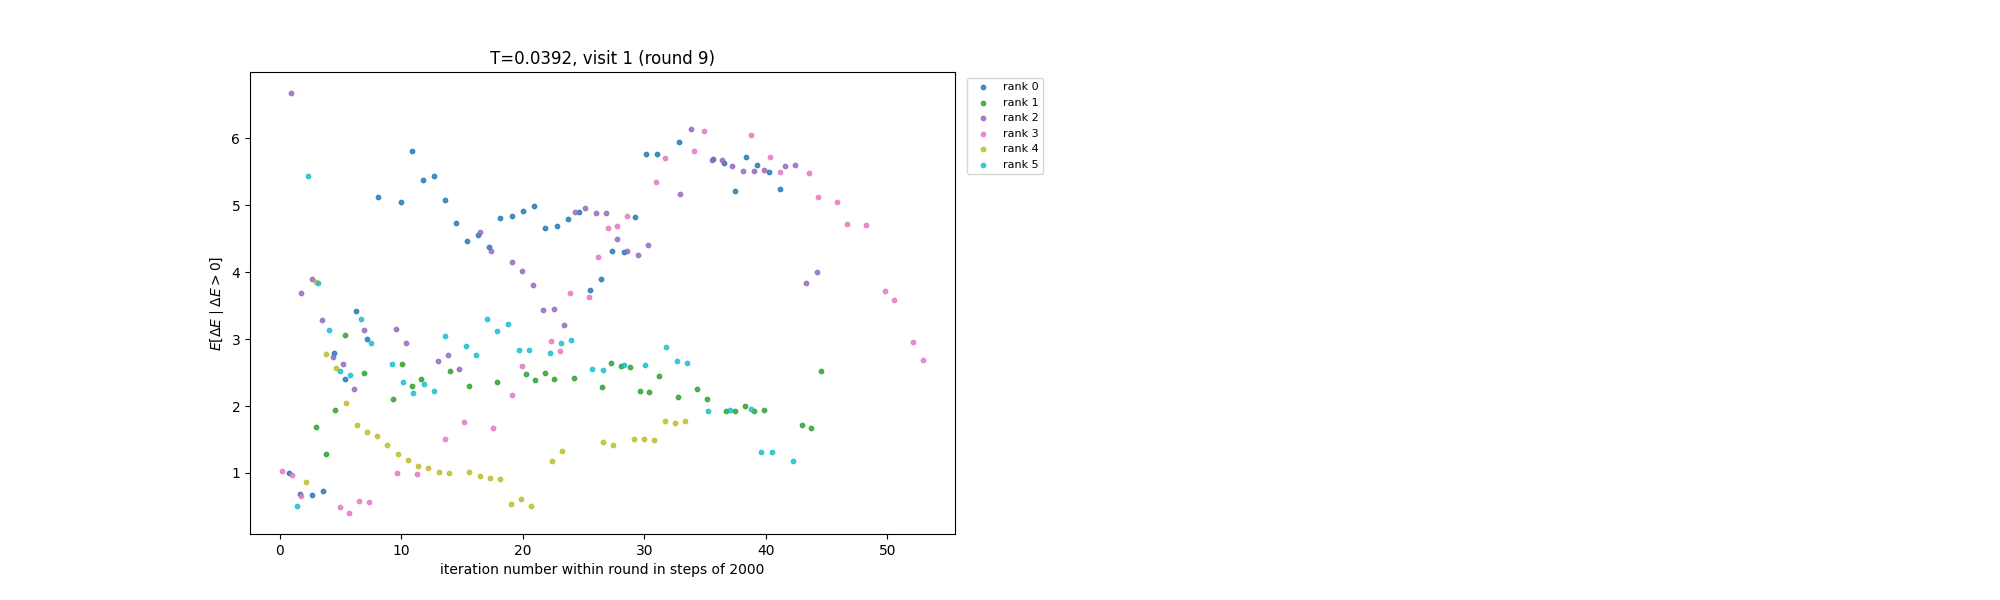

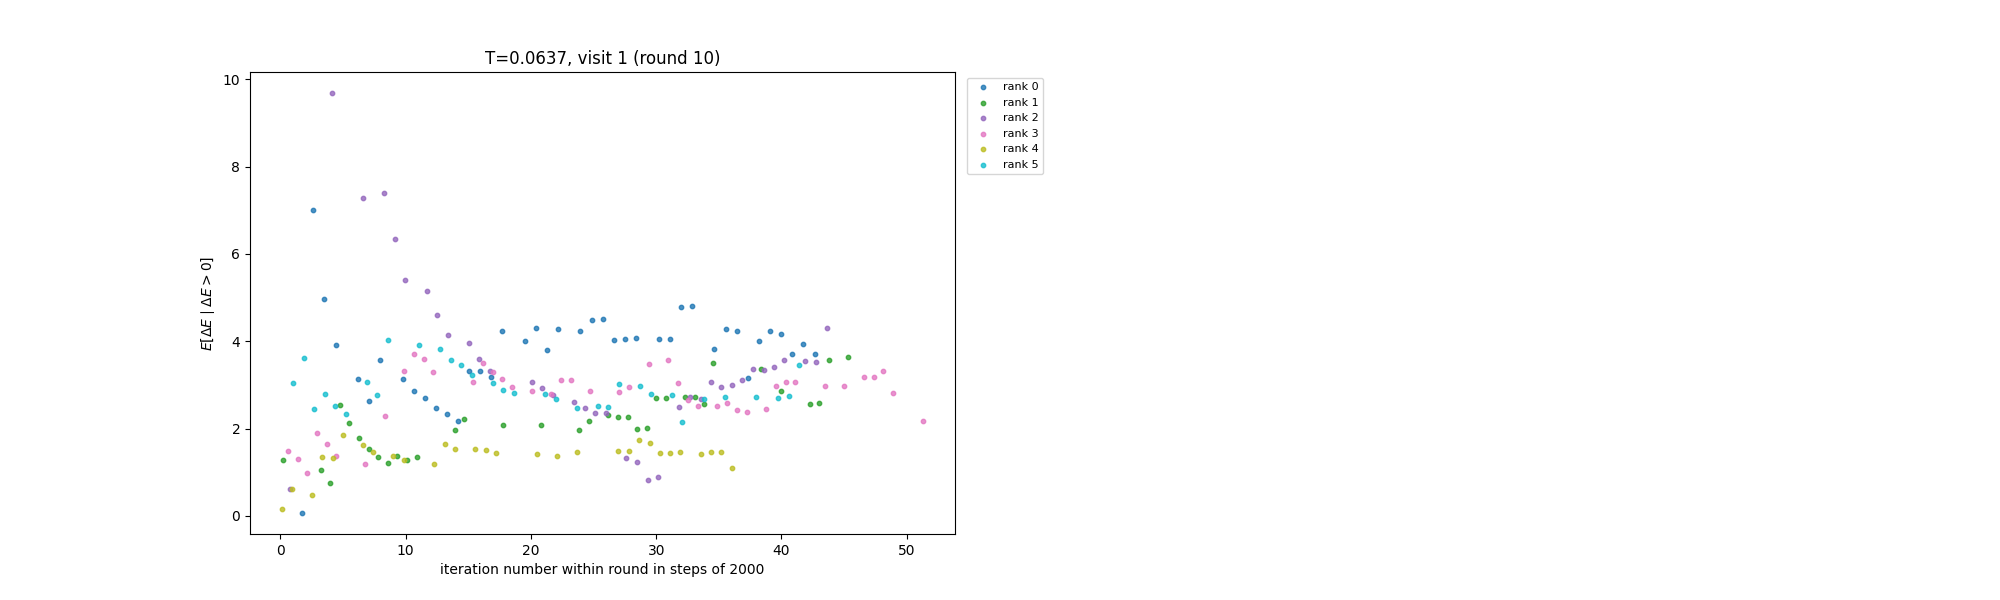

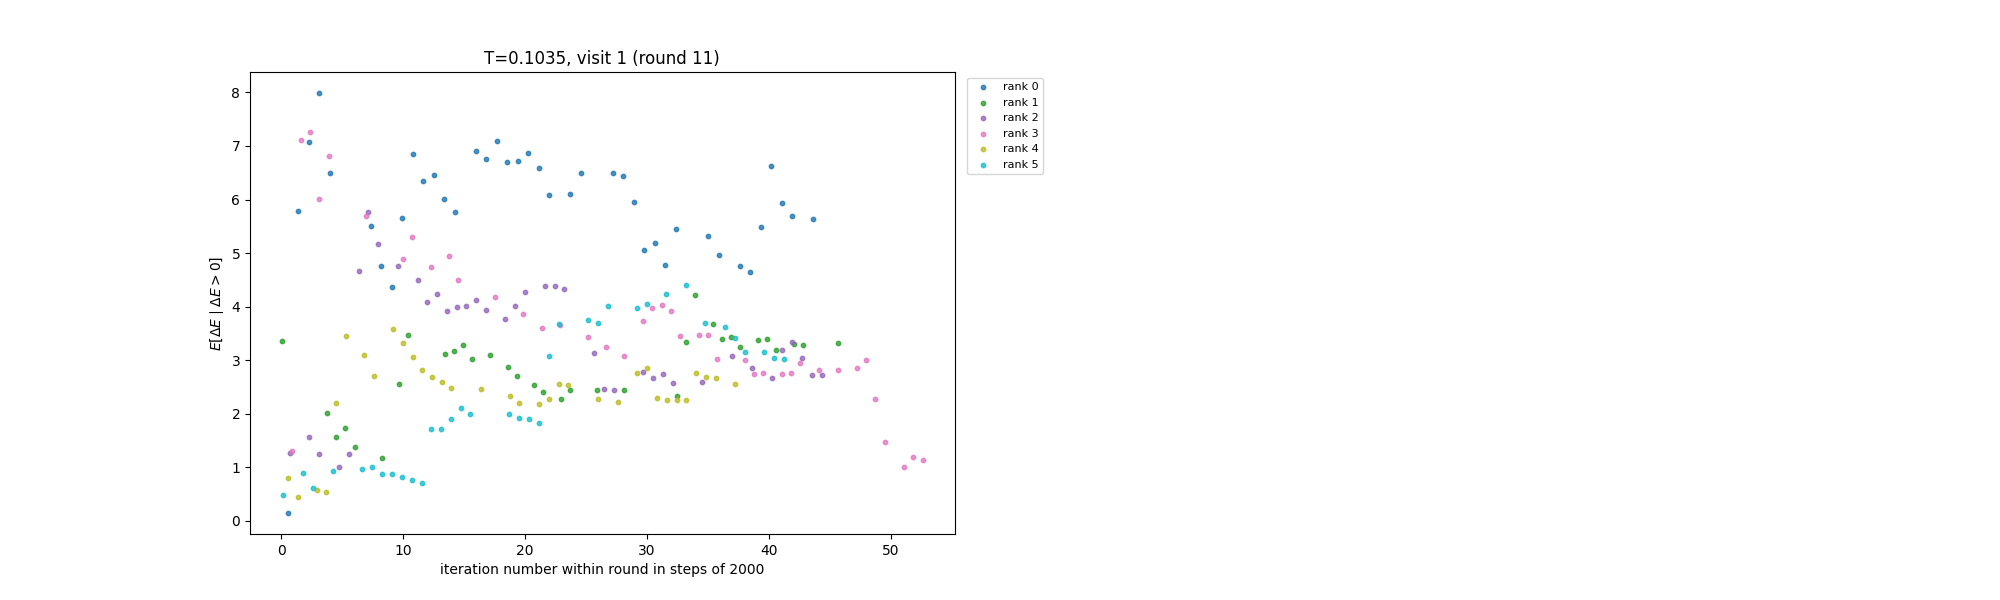

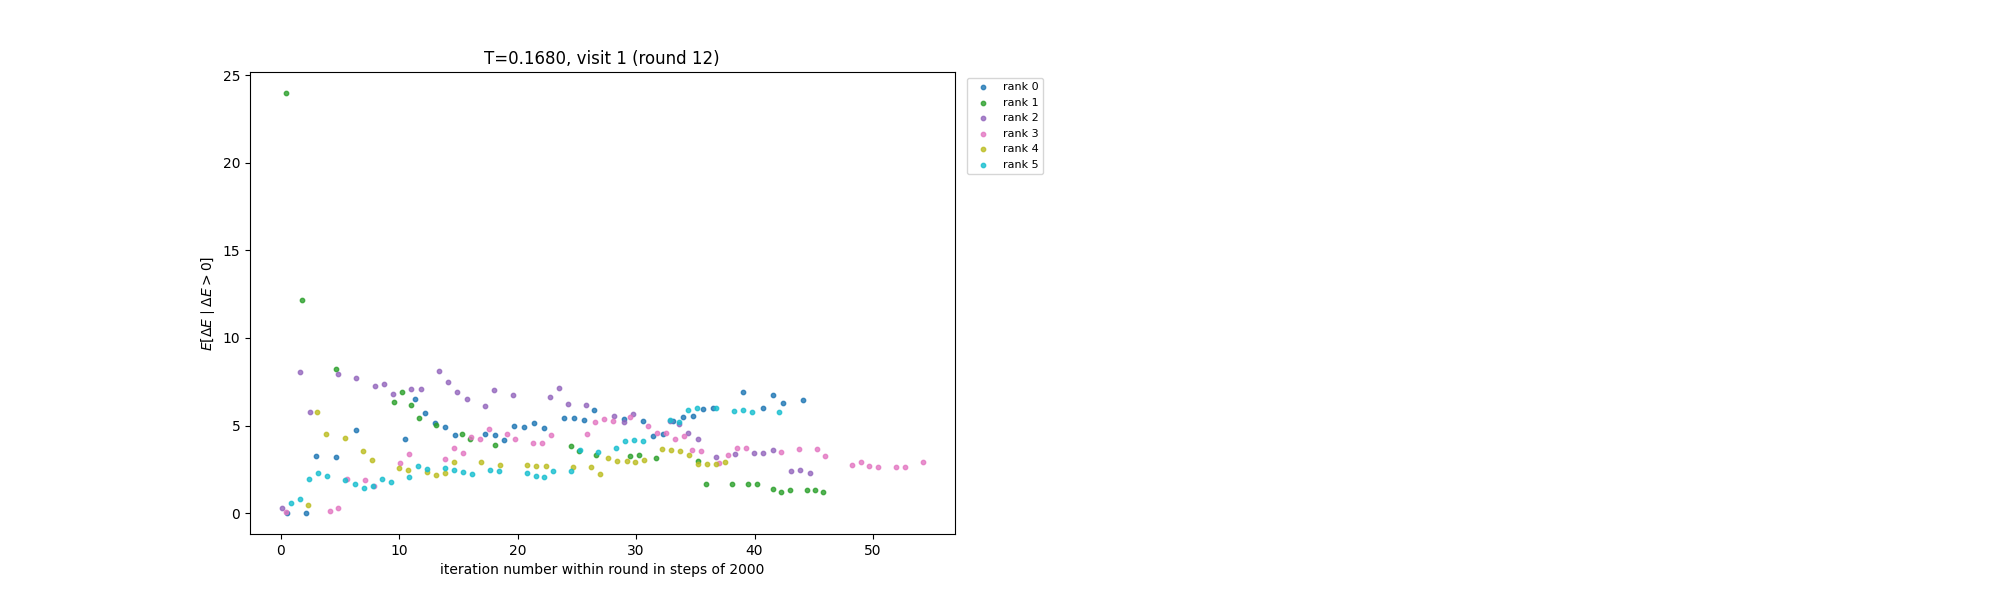

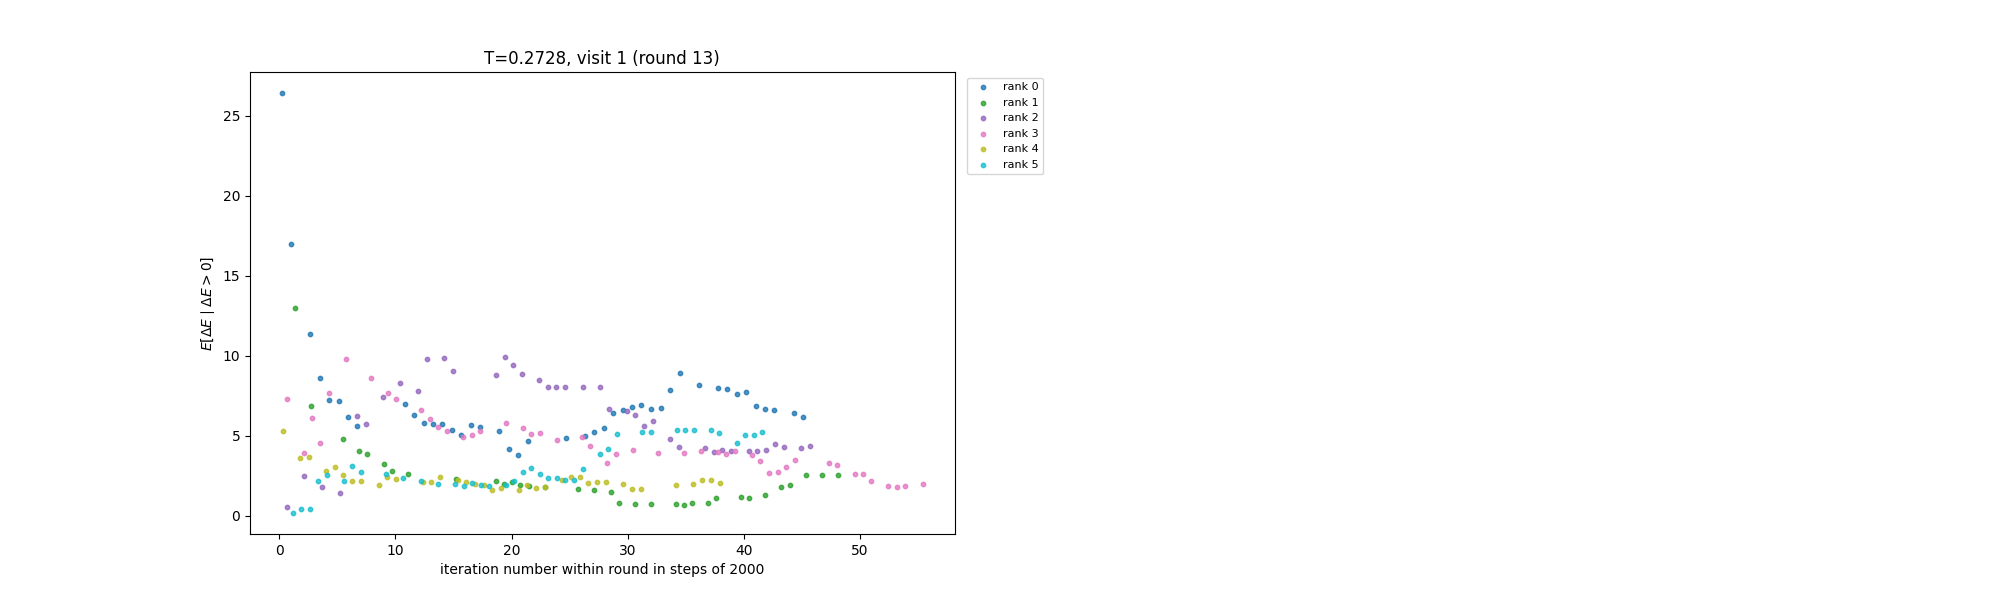

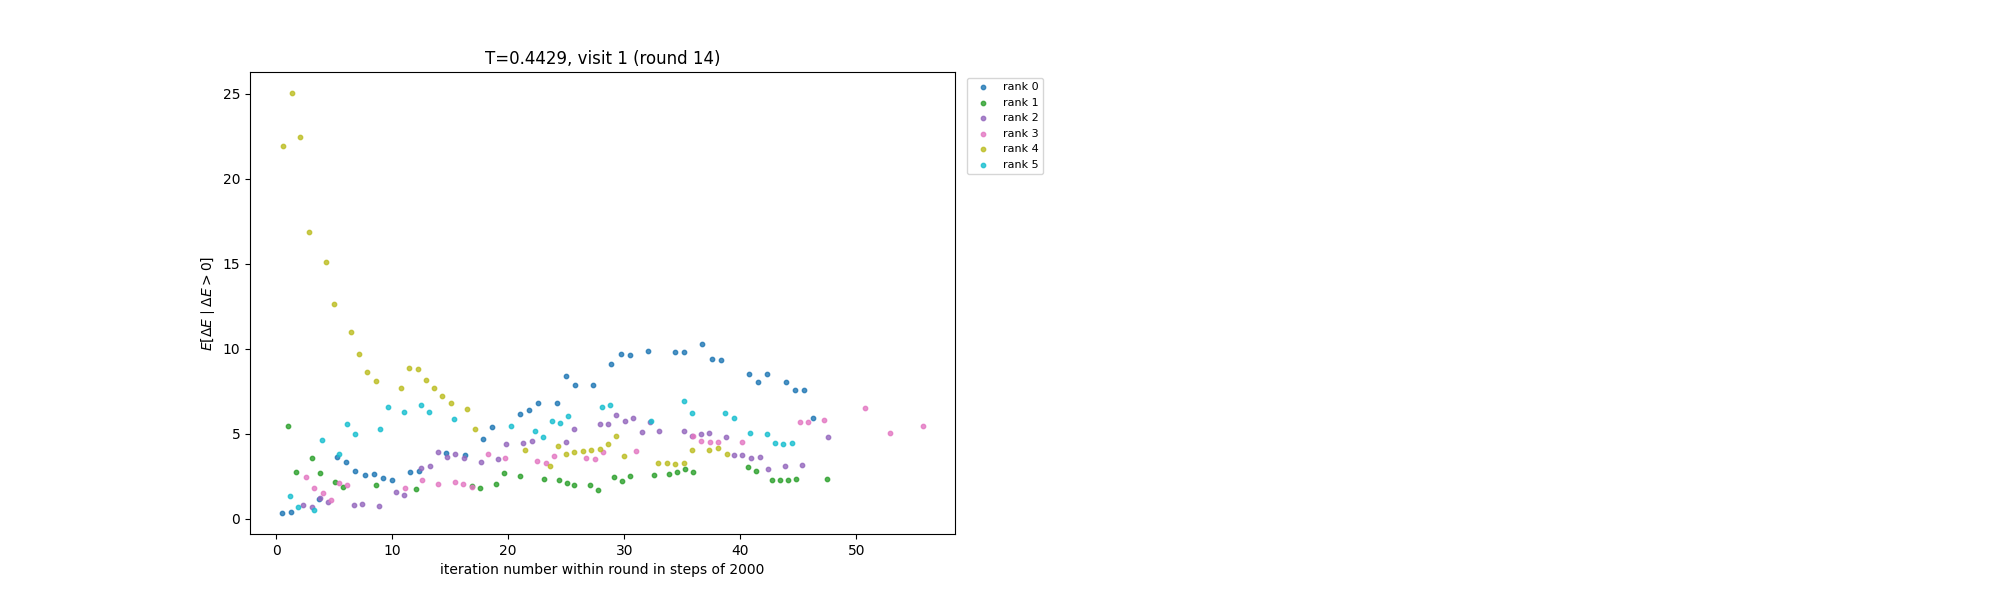

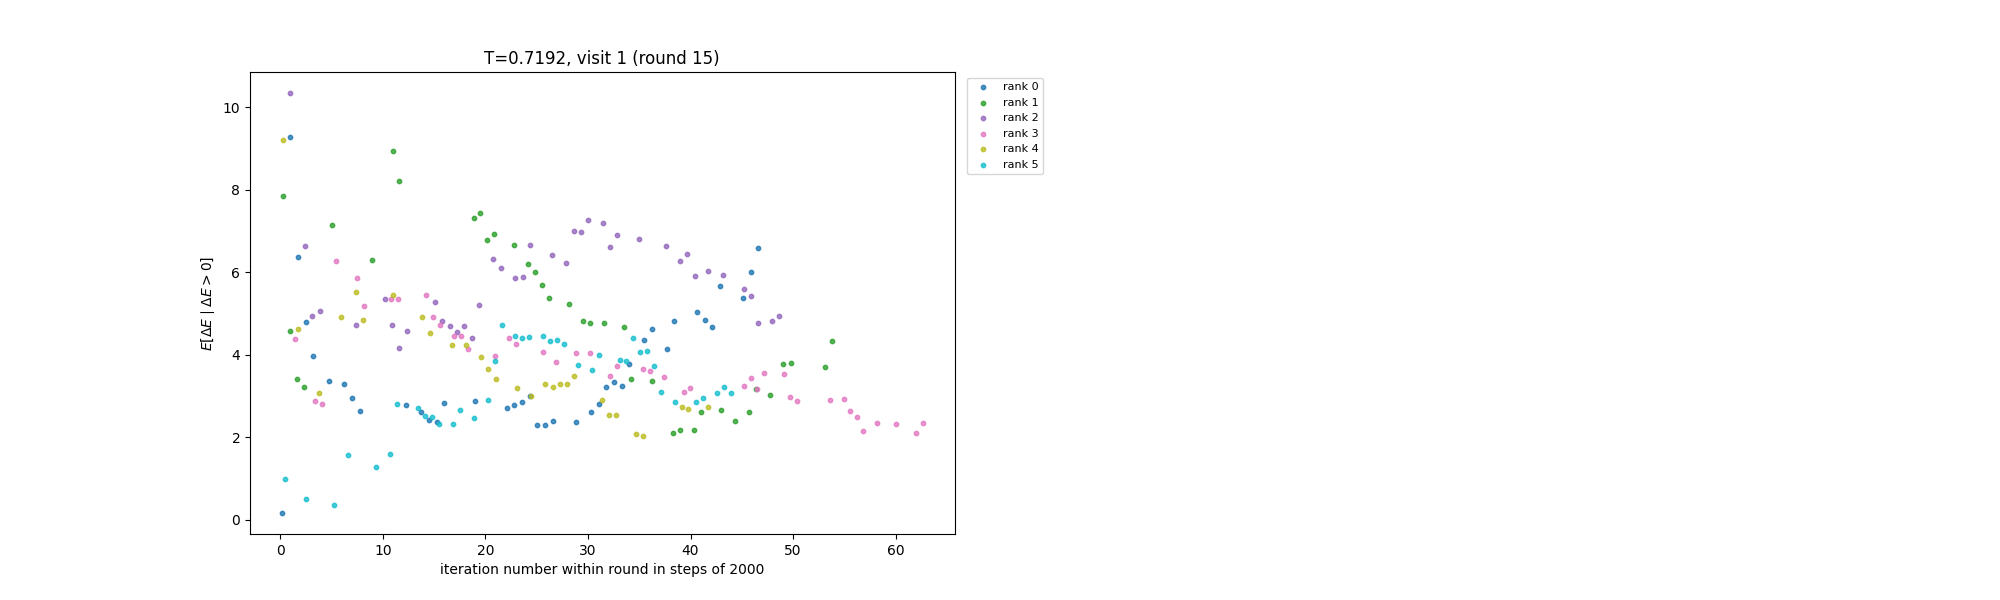

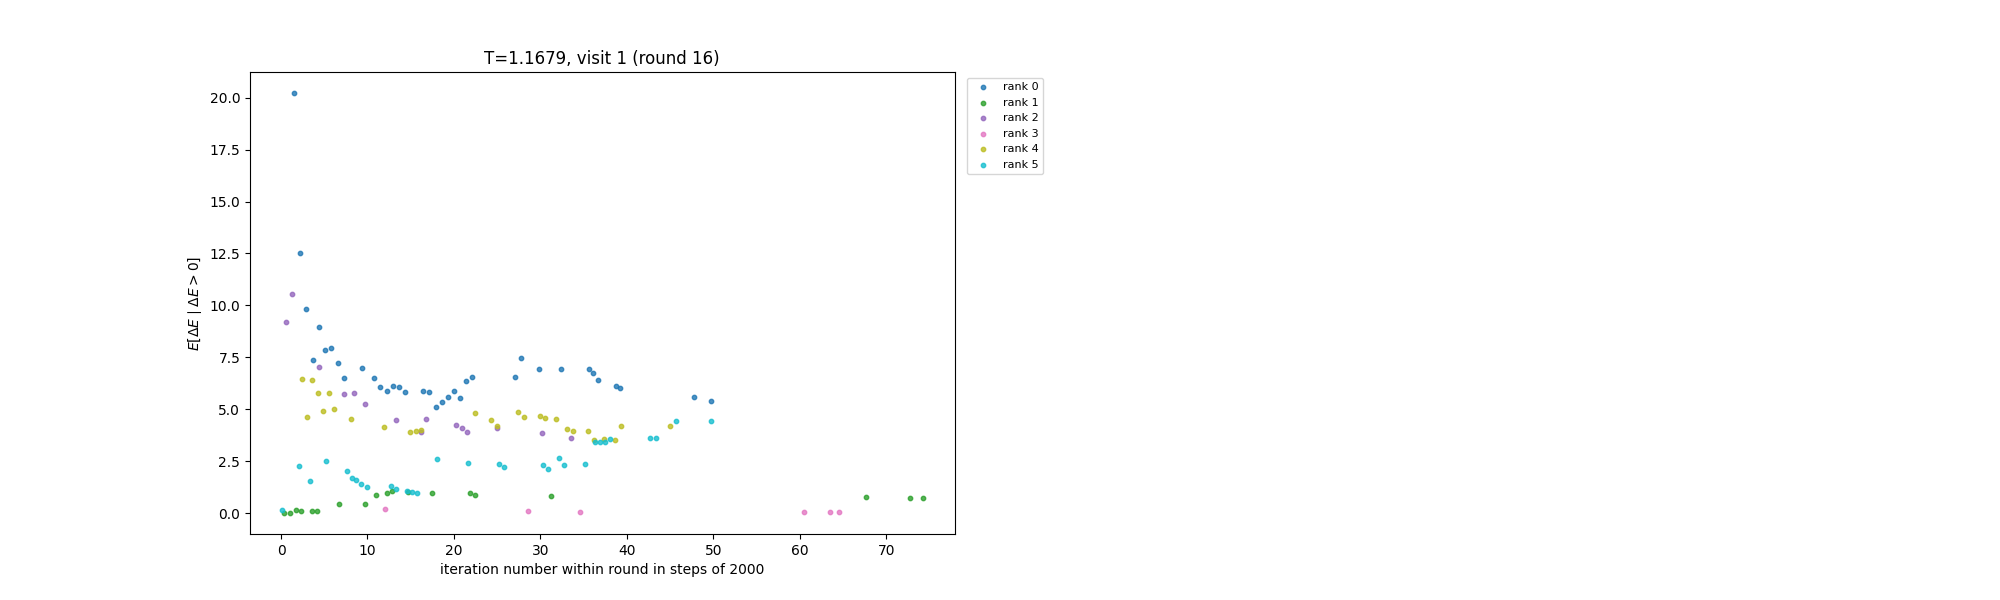

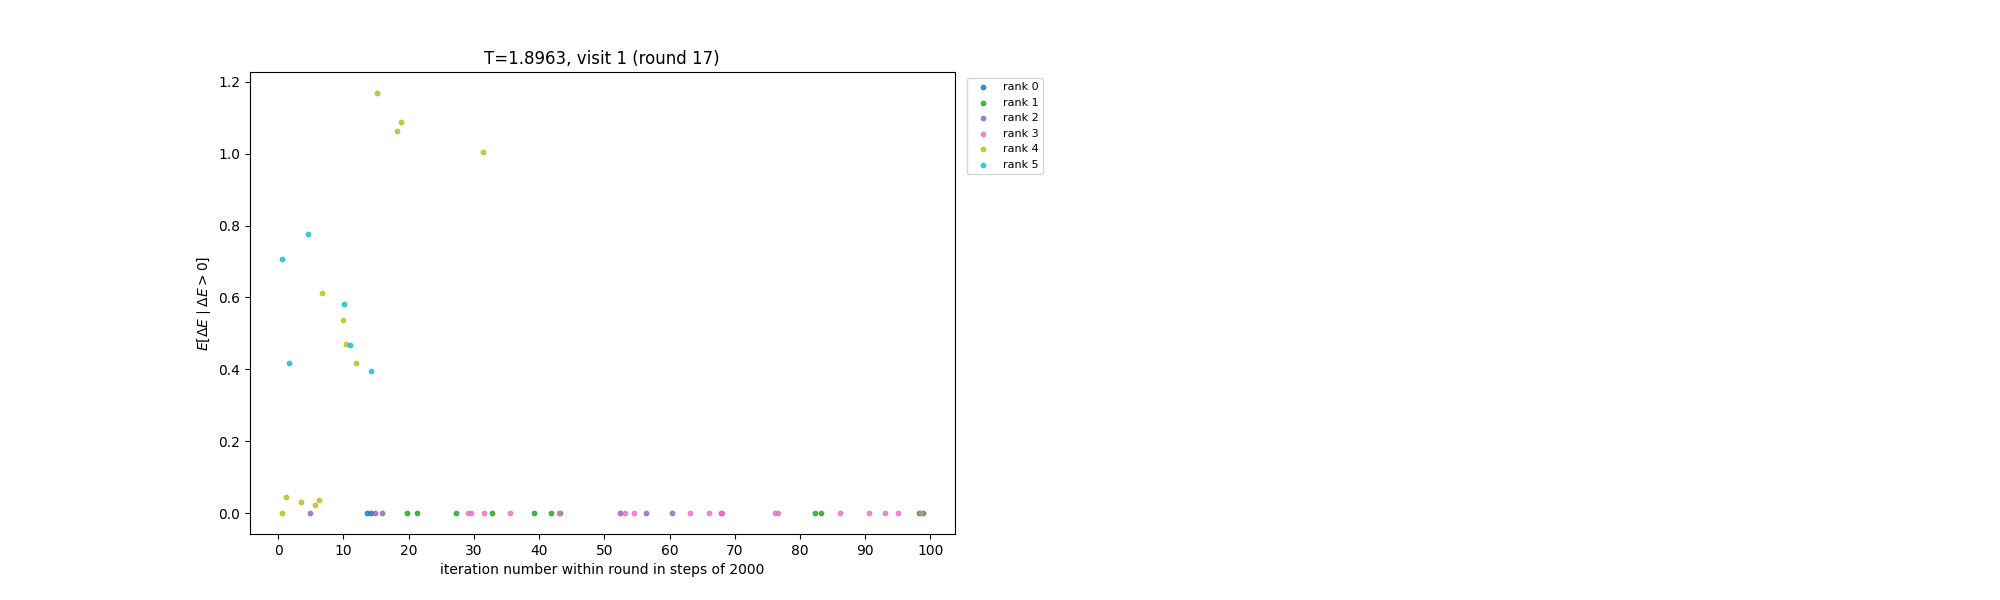

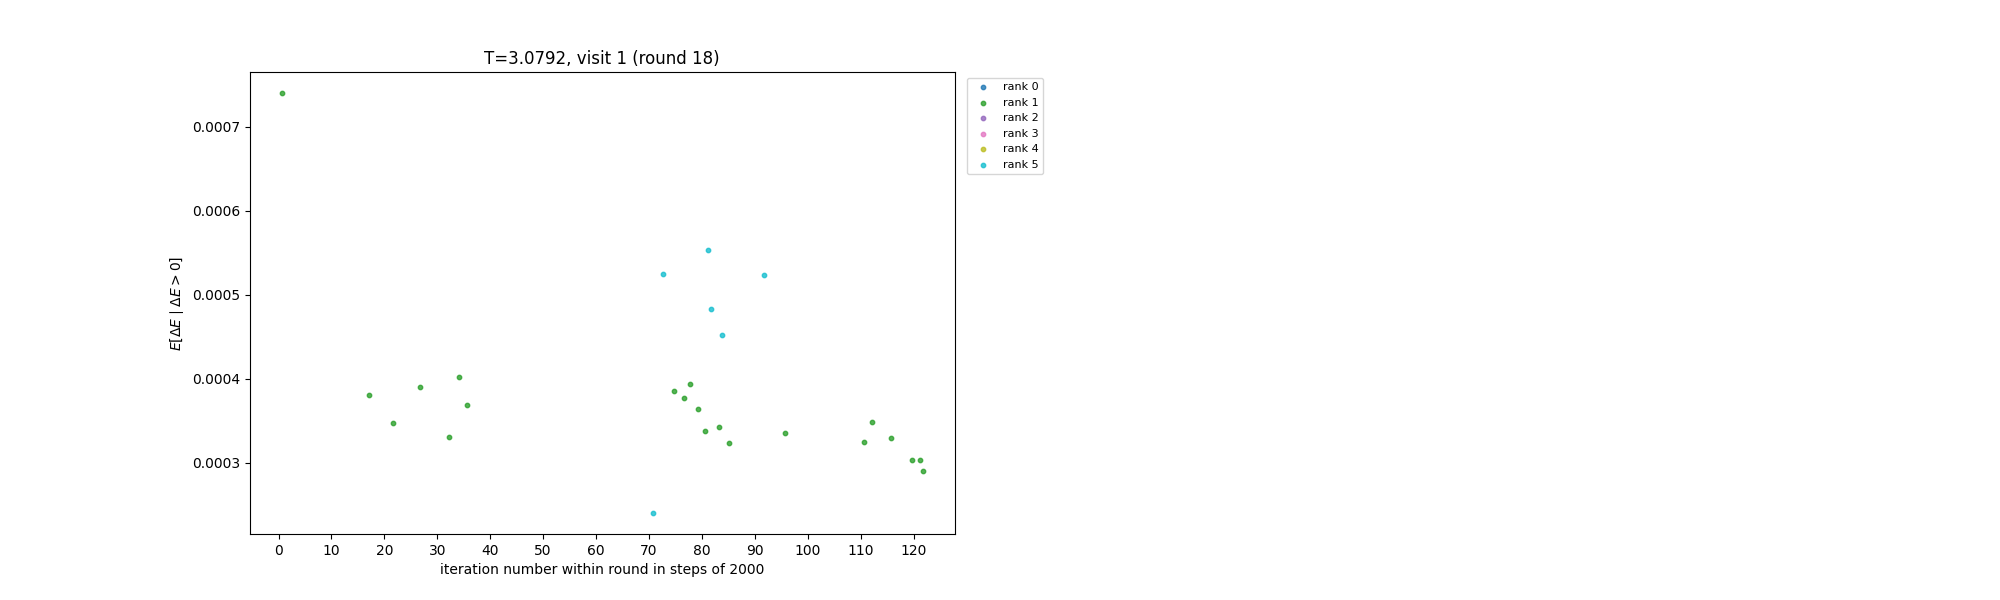

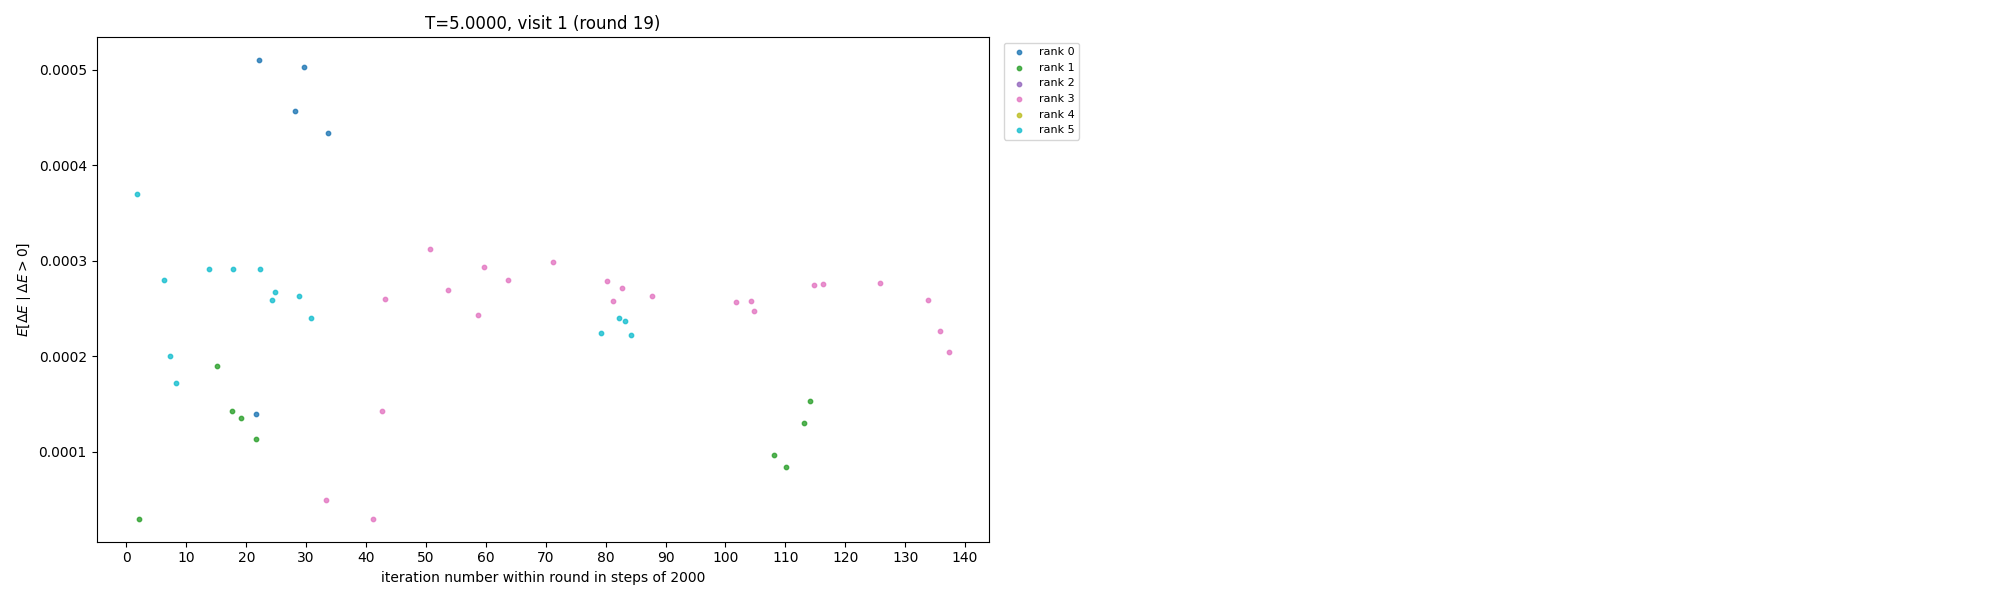

In [15]:
from matplotlib.ticker import MultipleLocator, FuncFormatter
unique_temps = sorted(df_exp_stats_intra_rounds['T'].unique())
cmap = plt.get_cmap('tab10', size)

for T in unique_temps:
    rounds_at_T = sorted(df_exp_stats_intra_rounds[df_exp_stats_intra_rounds['T'] == T]['round_nbr'].unique())
    n_visits = len(rounds_at_T)

    fig = plt.figure(figsize=(20, 6))
    gs = fig.add_gridspec(1, 2)
    axes = [fig.add_subplot(gs[0, i]) for i in range(n_visits)]
    if n_visits == 2:
        axes[1].sharey(axes[0])

    for visit_idx, round_nbr in enumerate(rounds_at_T):
        ax = axes[visit_idx]
        round_data = energy_increasing[energy_increasing['round_nbr'] == round_nbr]

        for rank in range(size):
            rank_data = round_data[round_data['rank'] == rank]
            ax.scatter(rank_data['it_no_intra_round'], rank_data['exp(delE)'], s=10,
                       color=cmap(rank), label=f'rank {rank}', alpha=0.8)

        ax.ticklabel_format(style='plain', axis='y')
        ax.set_xlabel('iteration number within round in steps of 2000')
        ax.xaxis.set_major_locator(MultipleLocator(20000))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/2000)}'))
        ax.set_ylabel(r'$E[\Delta E \mid \Delta E>0]$')
        ax.set_title(f'T={T:.4f}, visit {visit_idx+1} (round {round_nbr})')
        if visit_idx == n_visits - 1:
              ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()

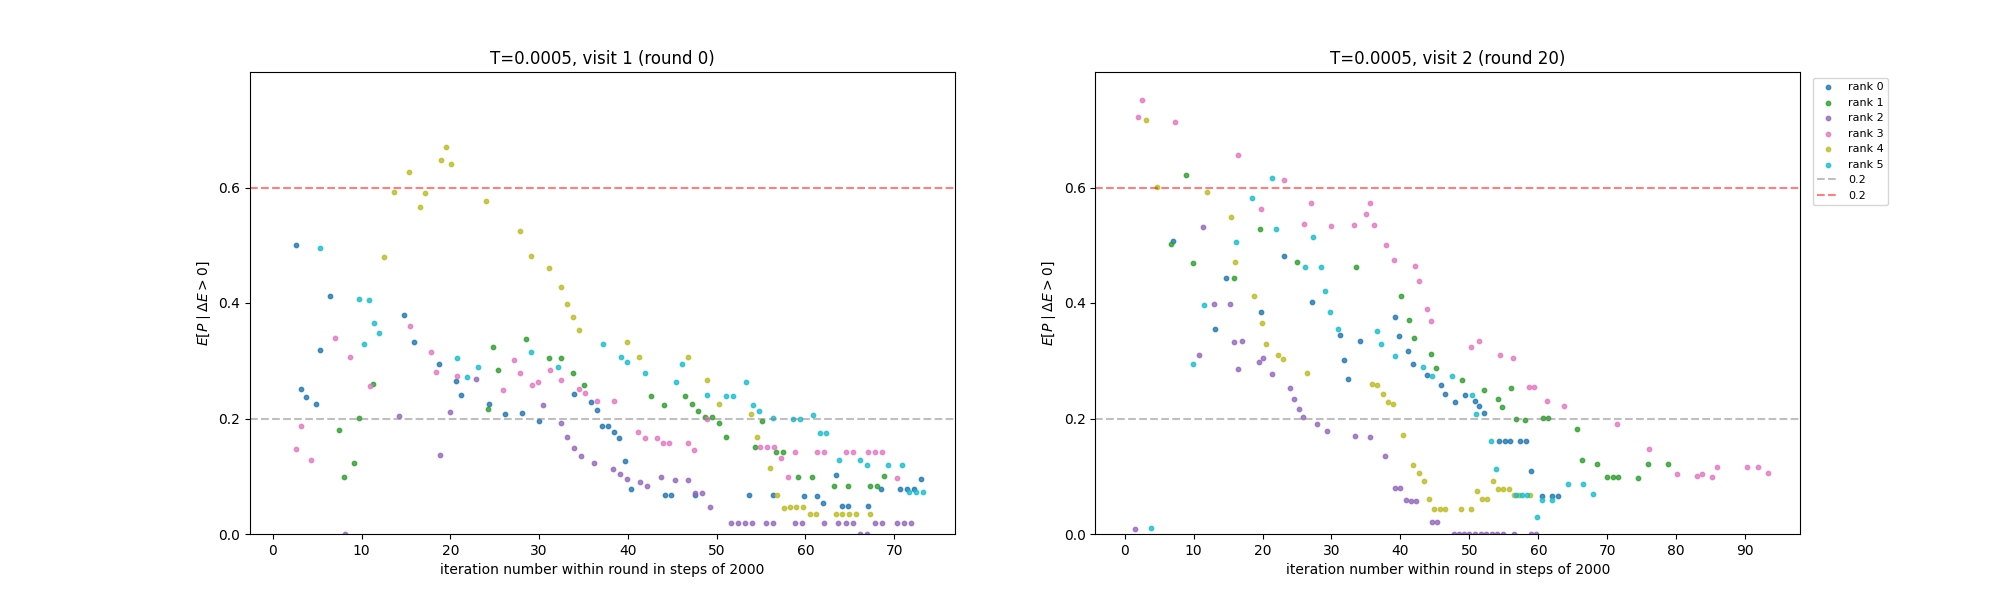

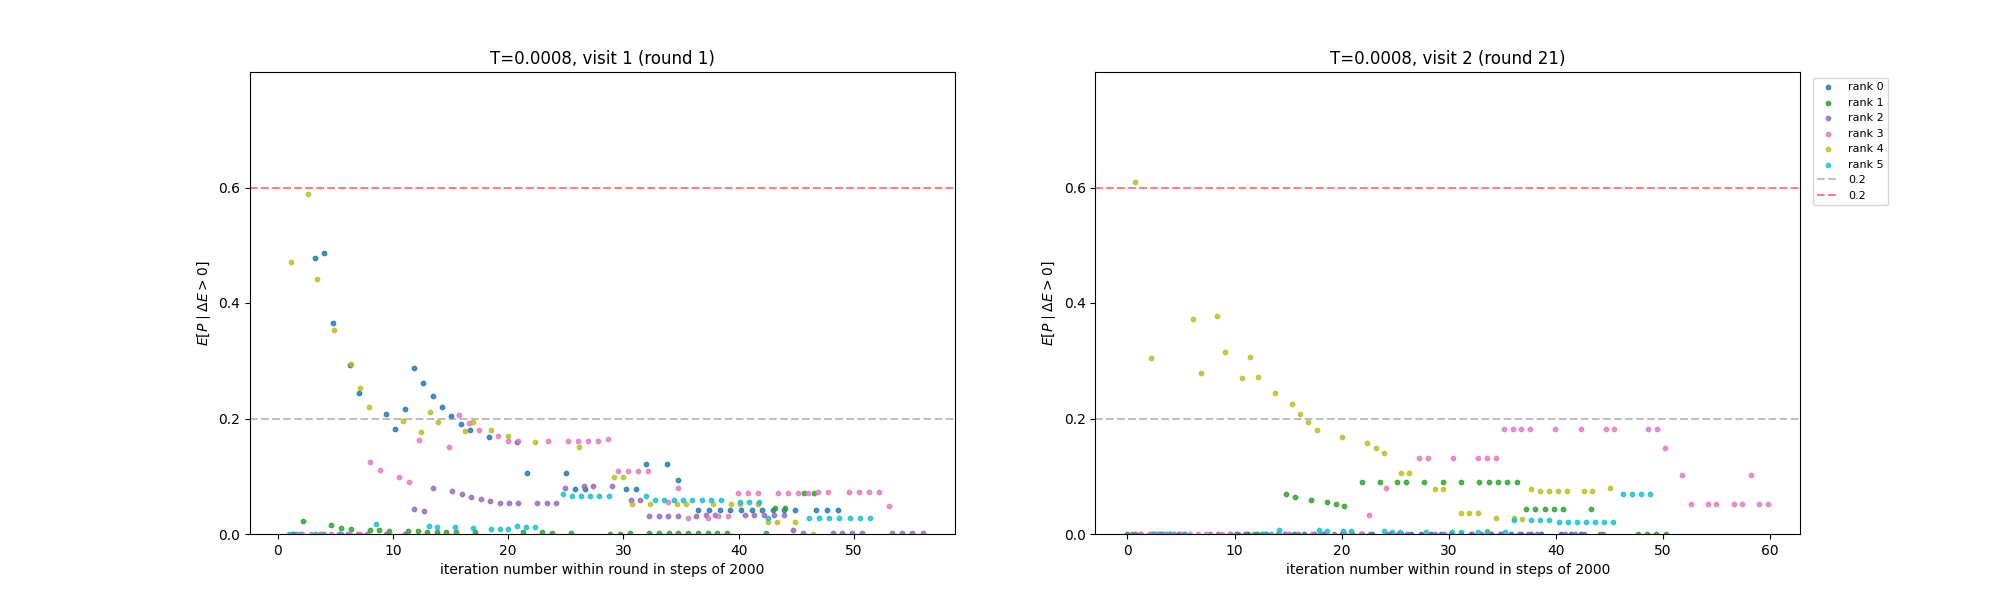

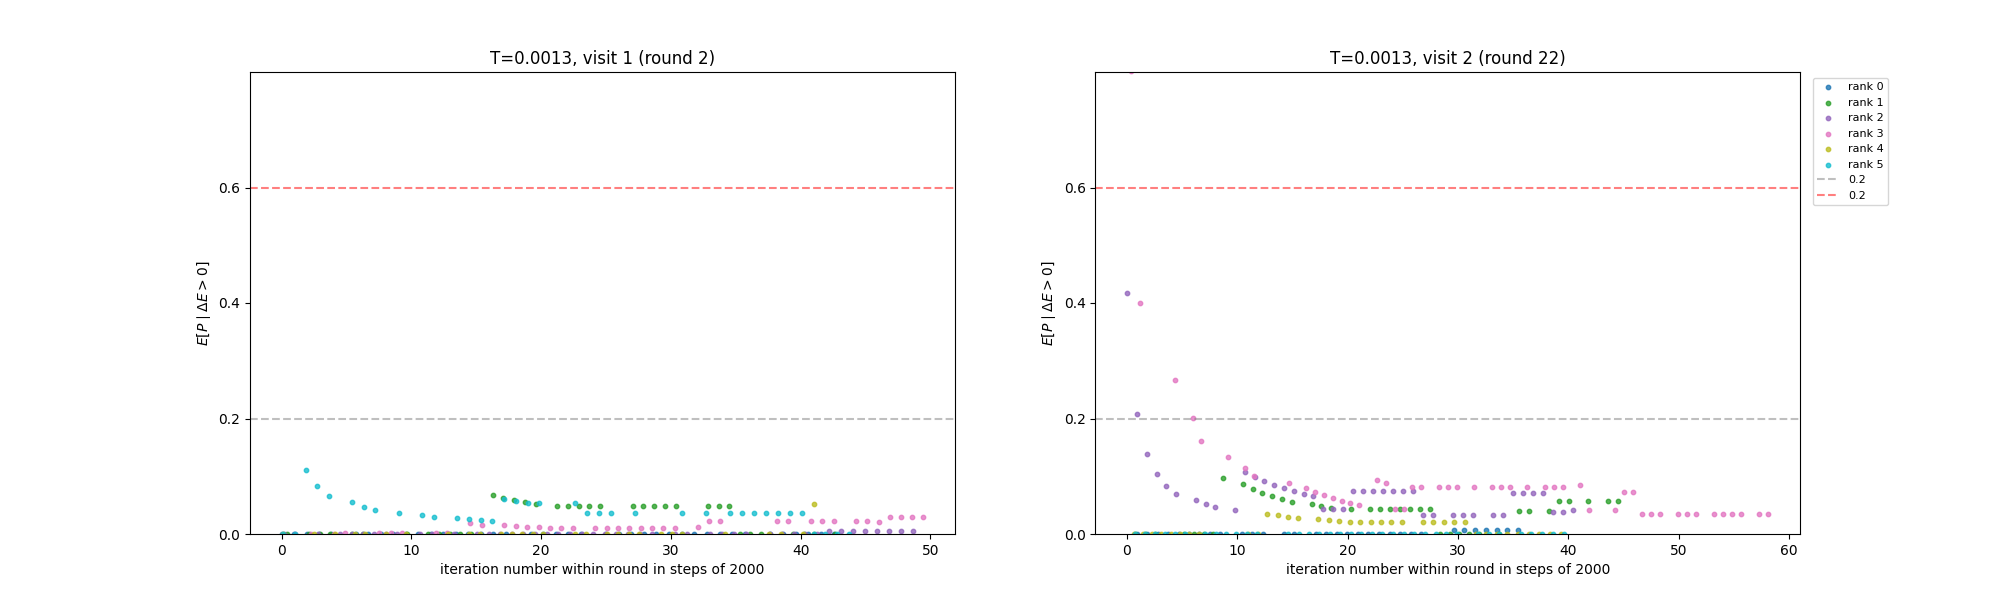

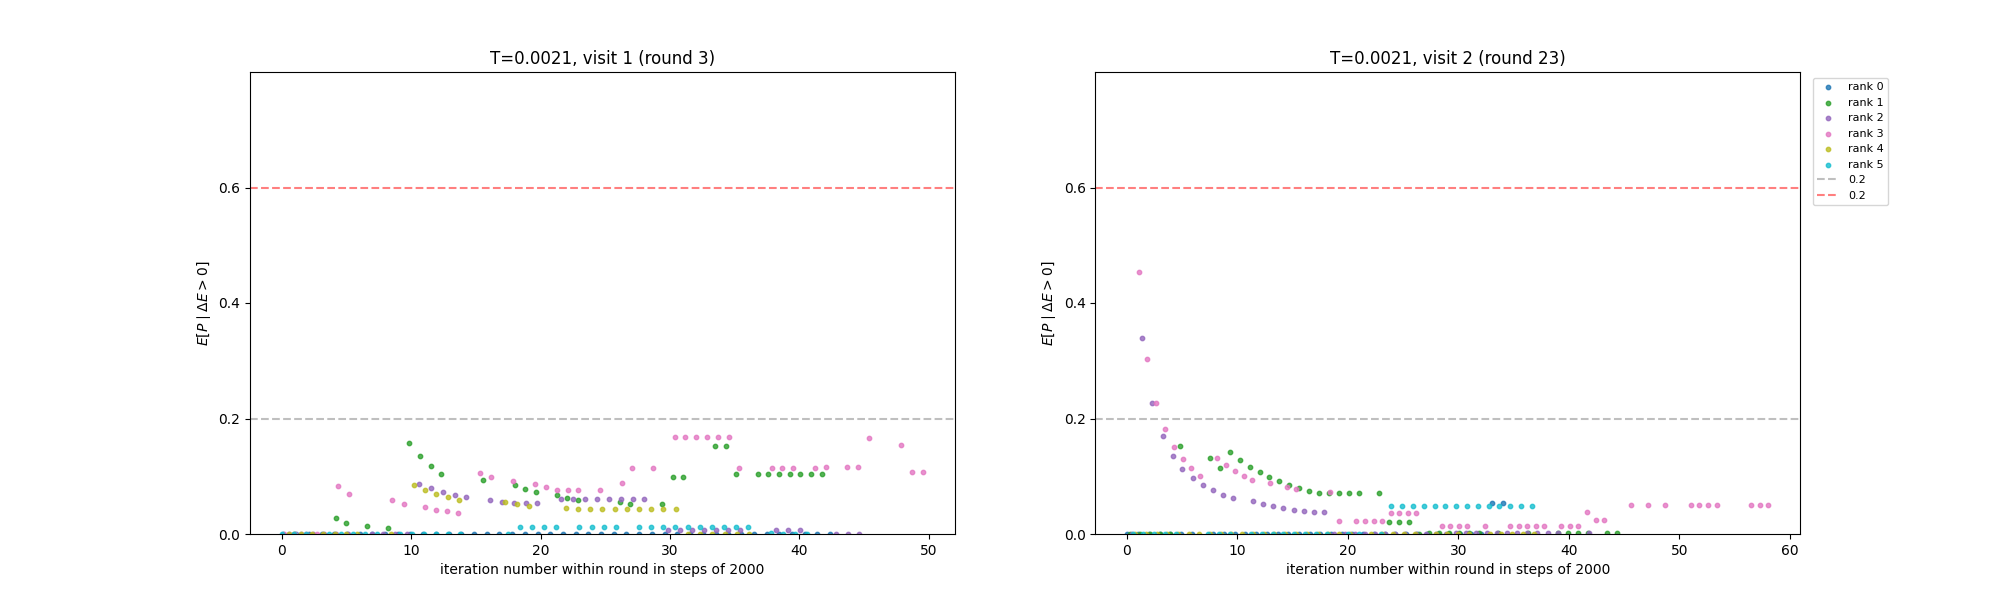

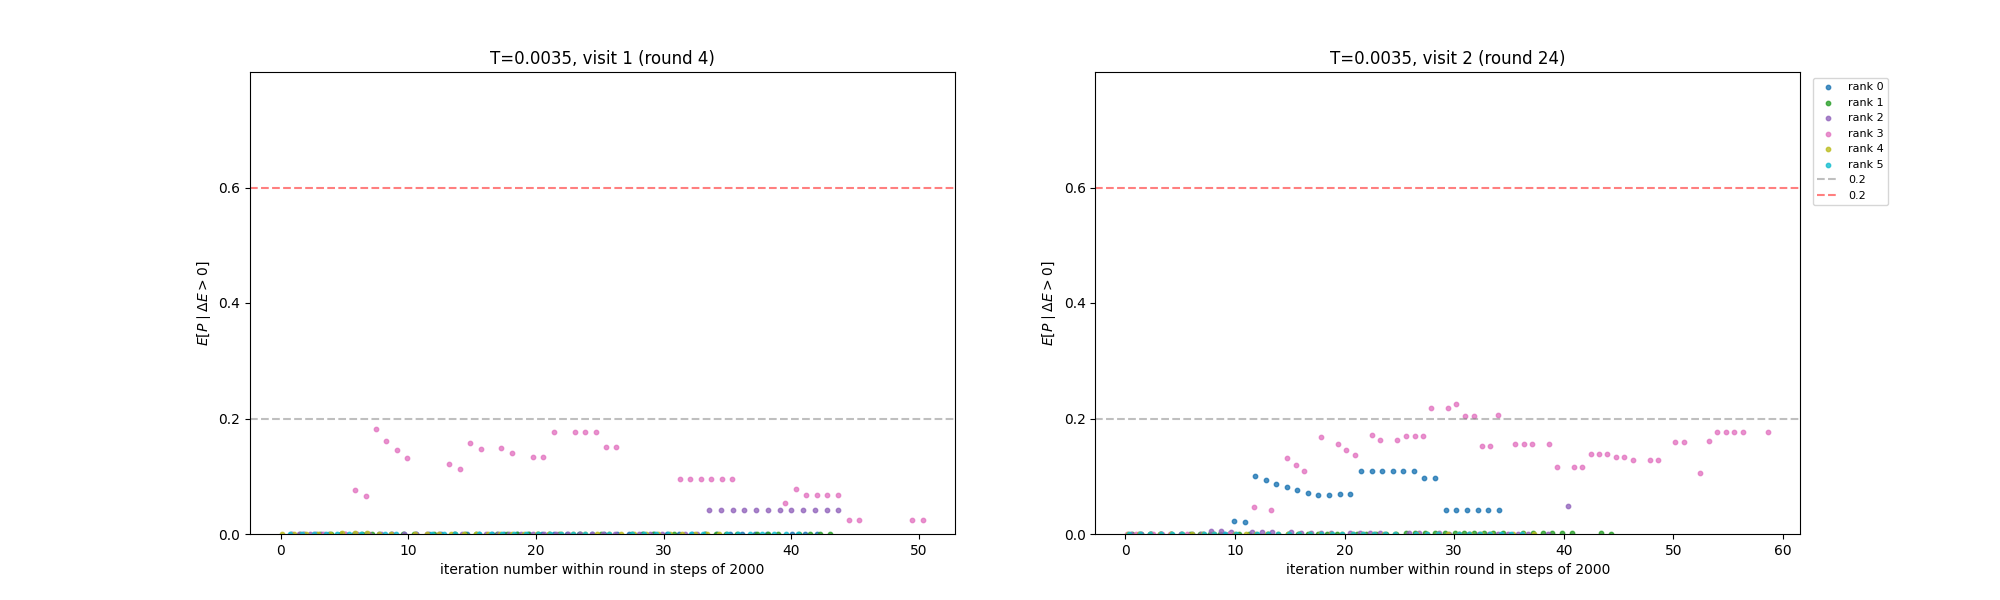

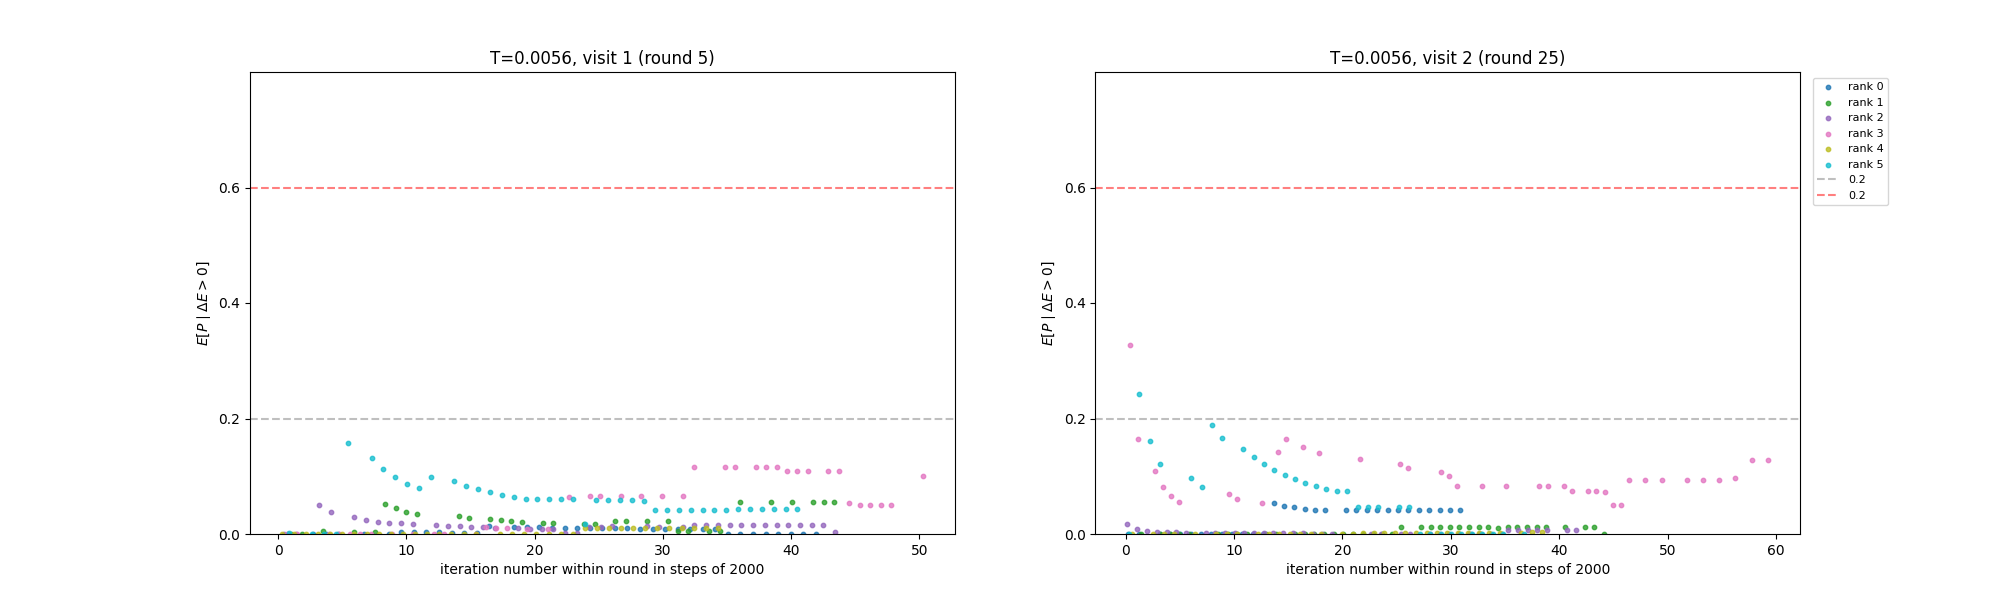

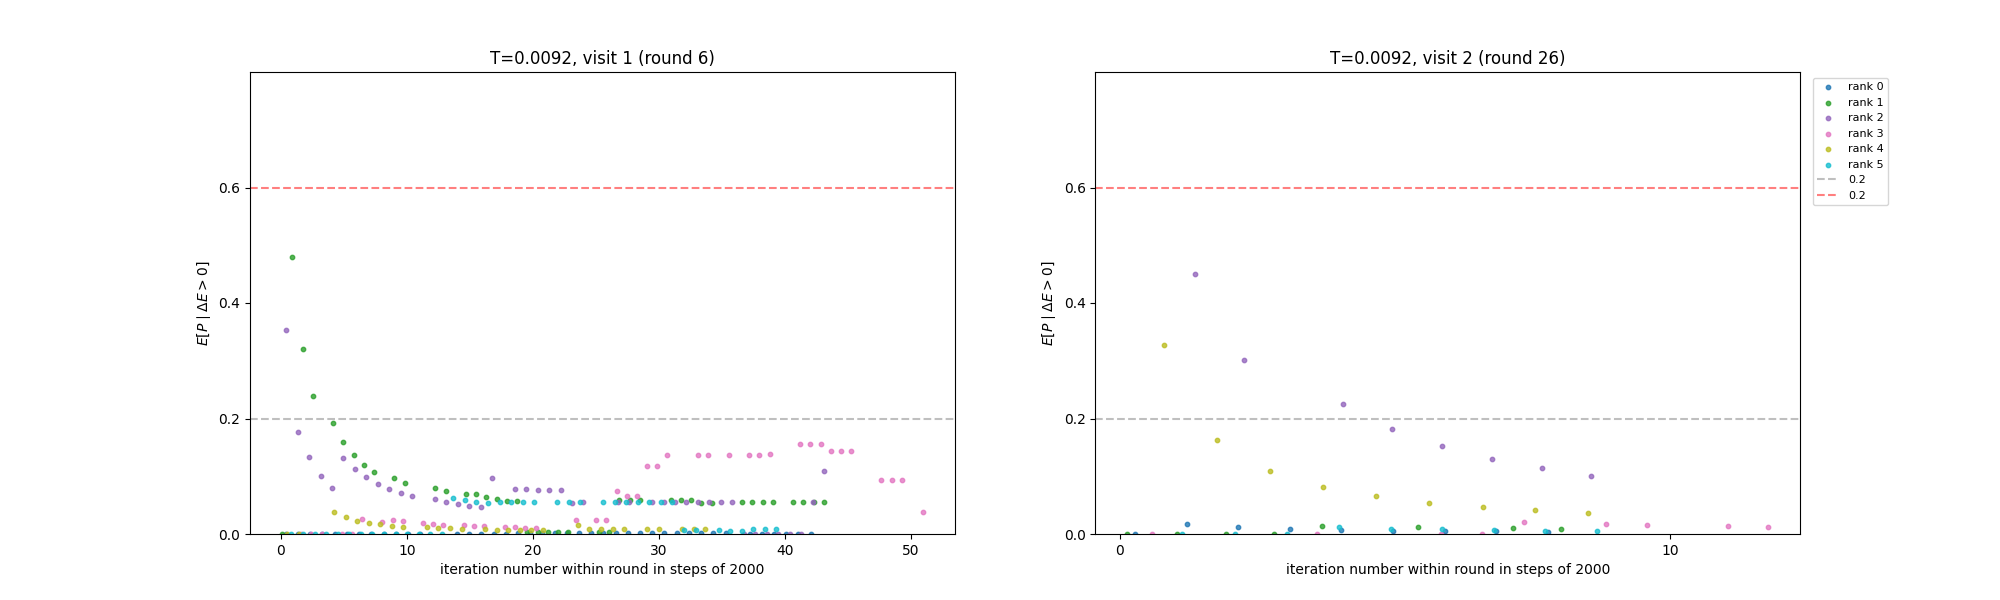

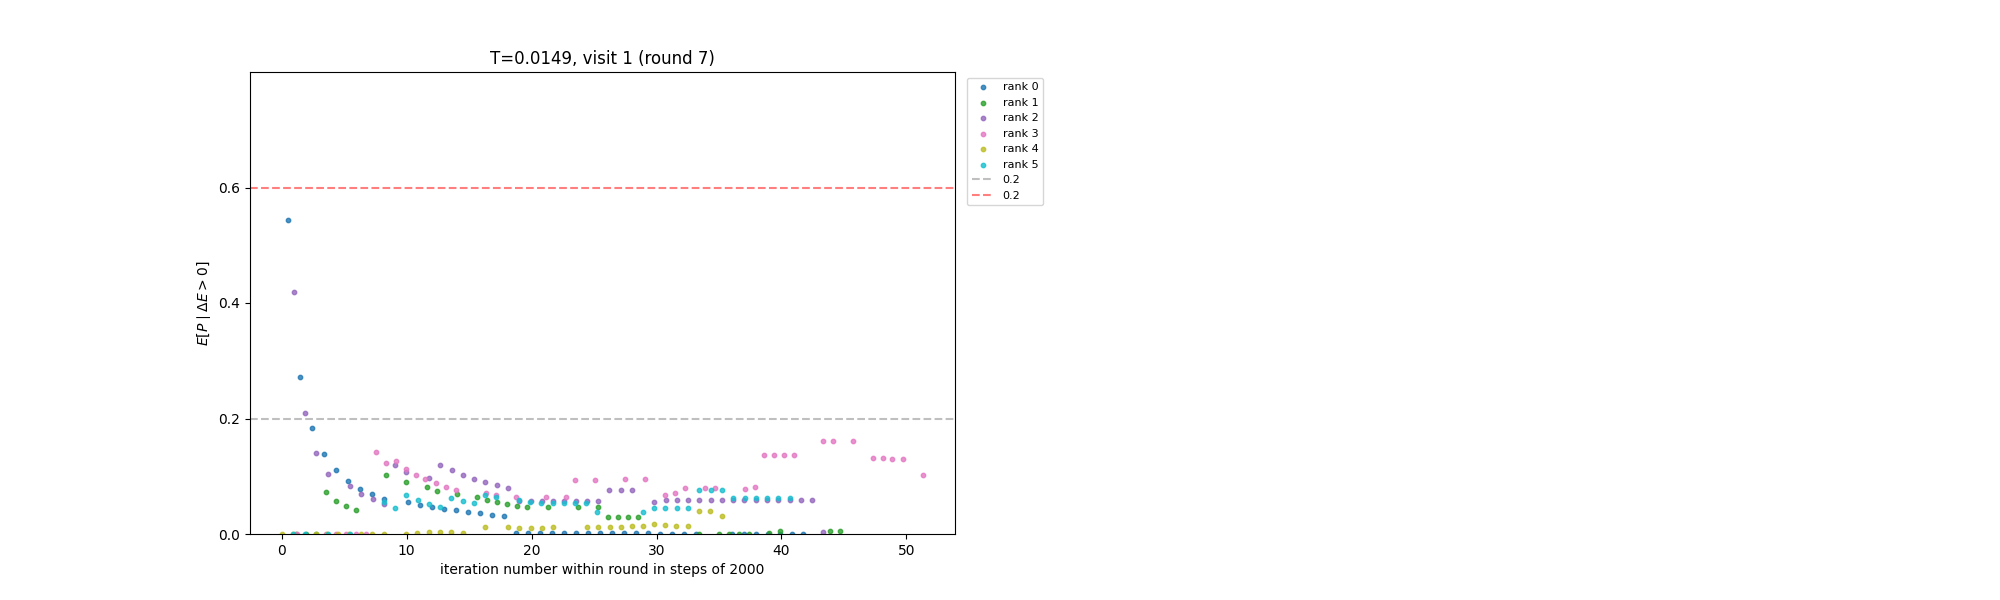

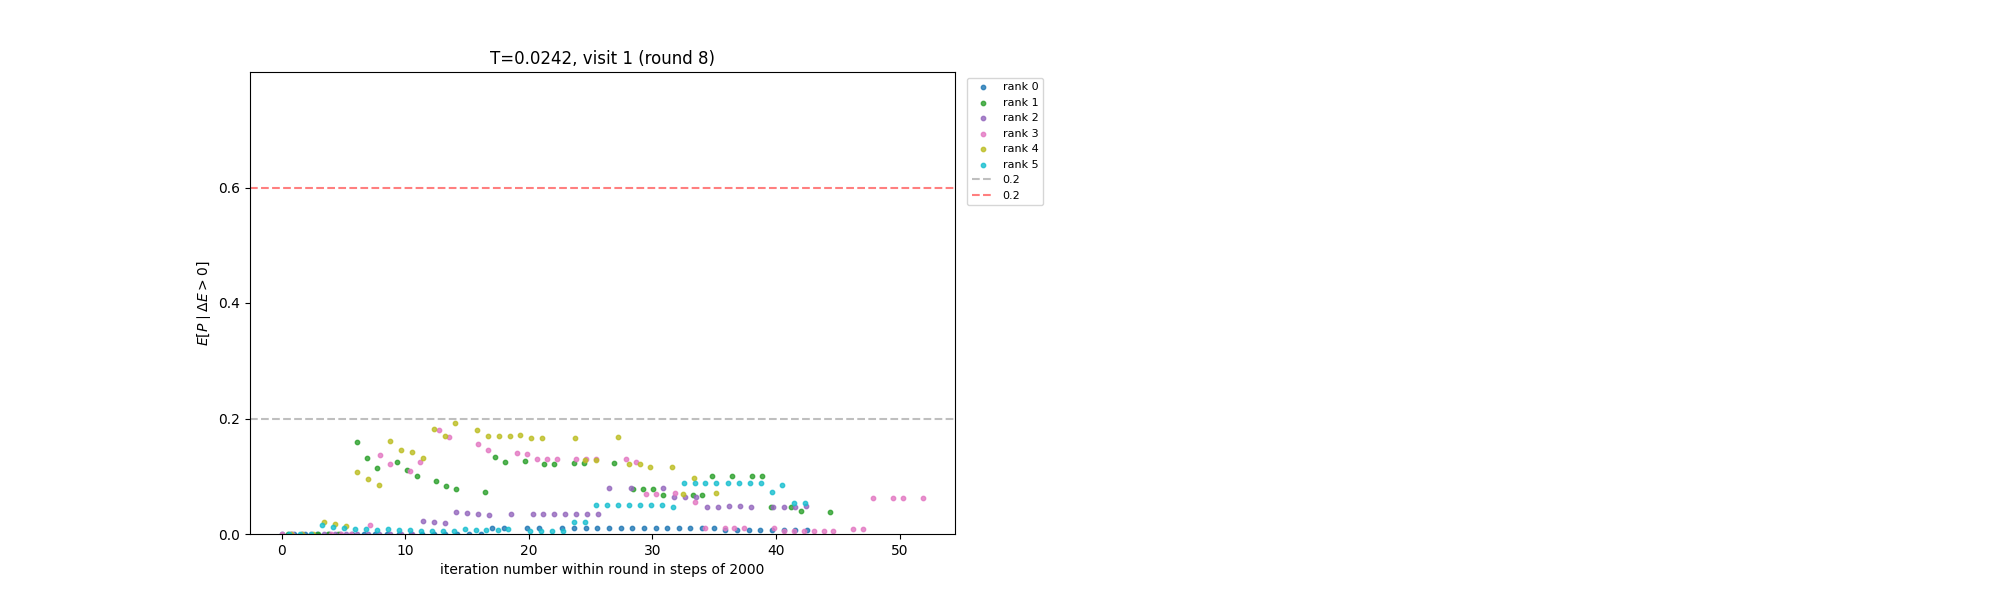

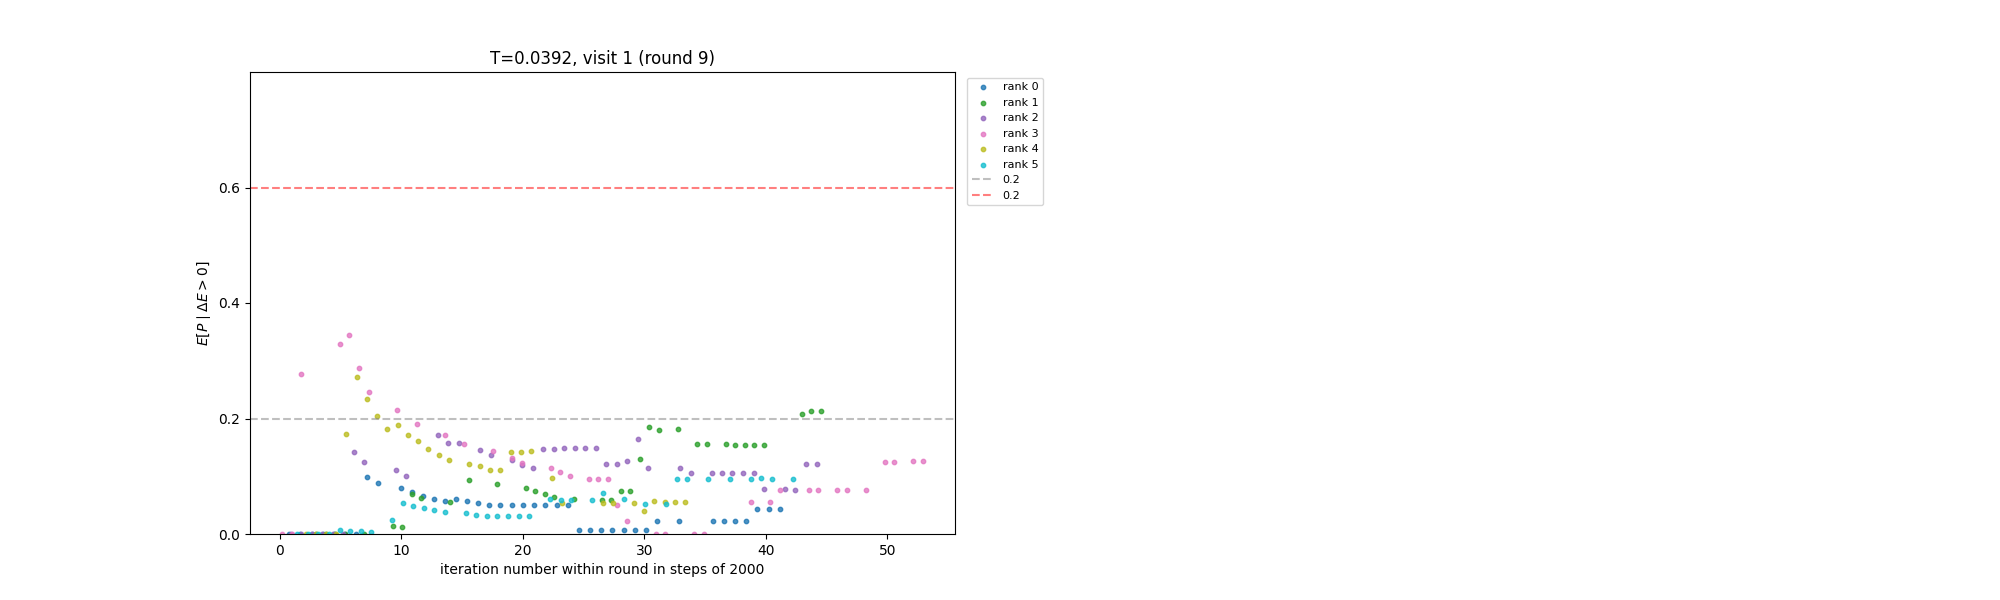

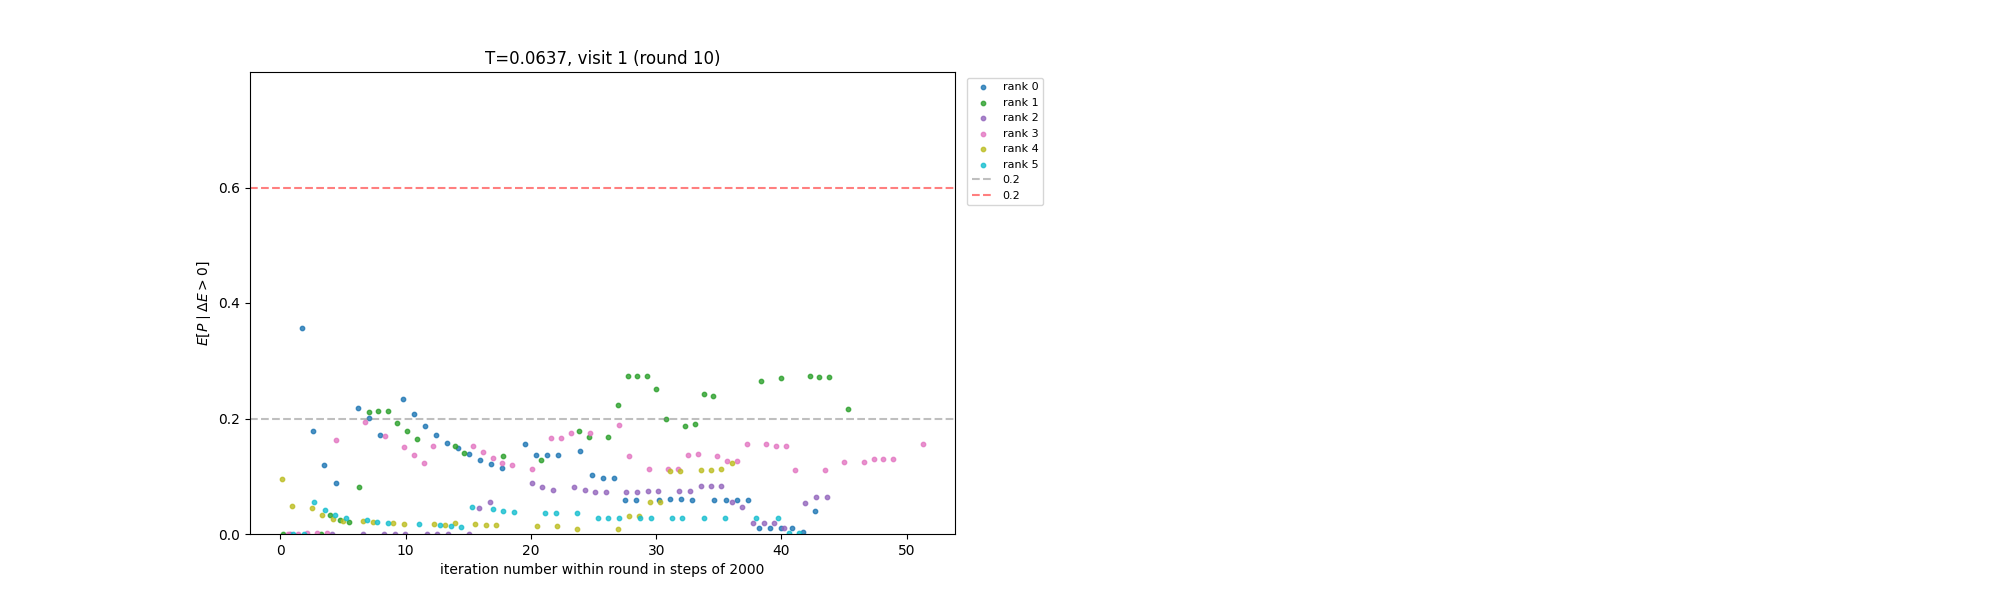

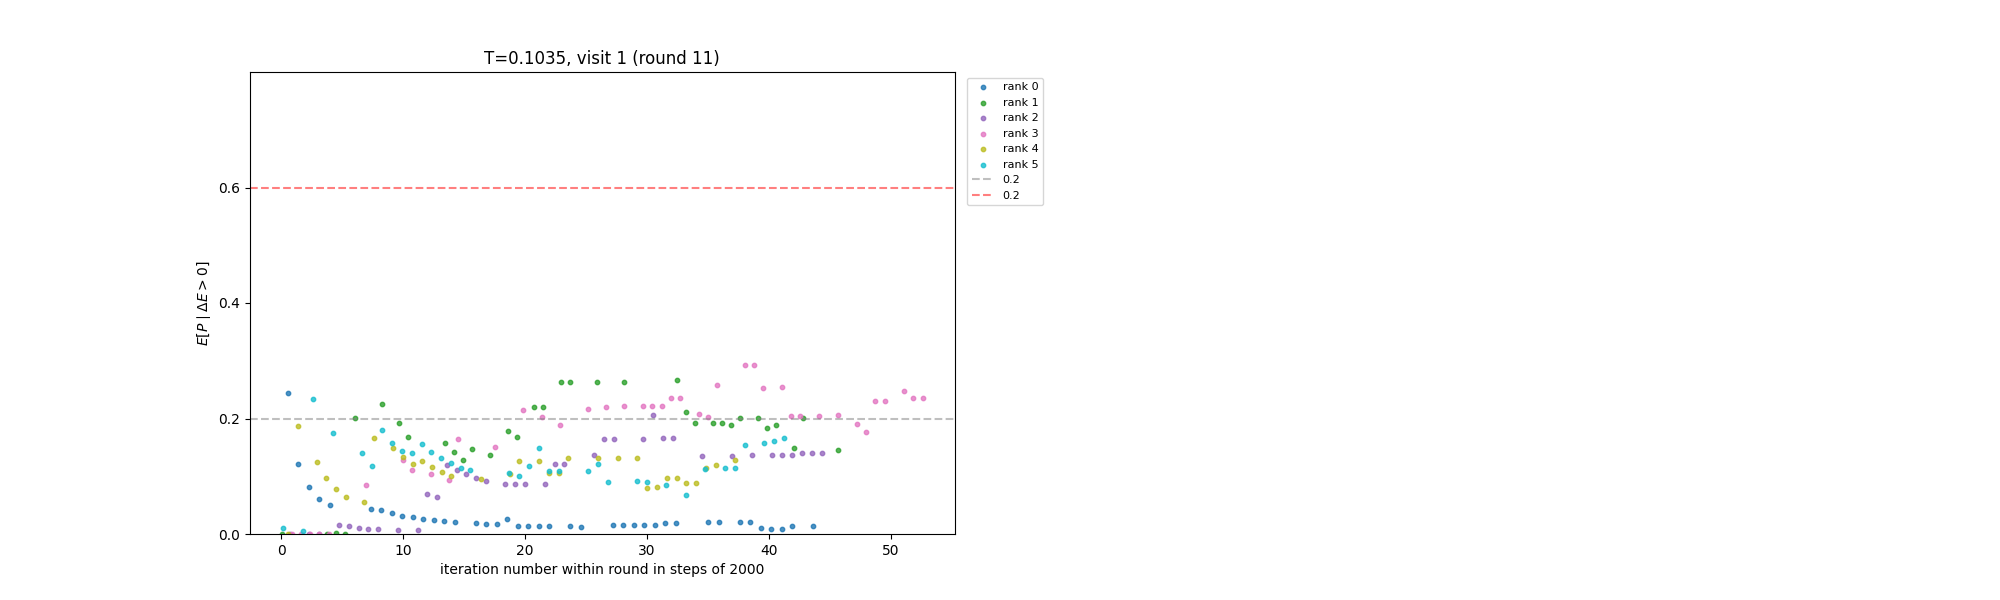

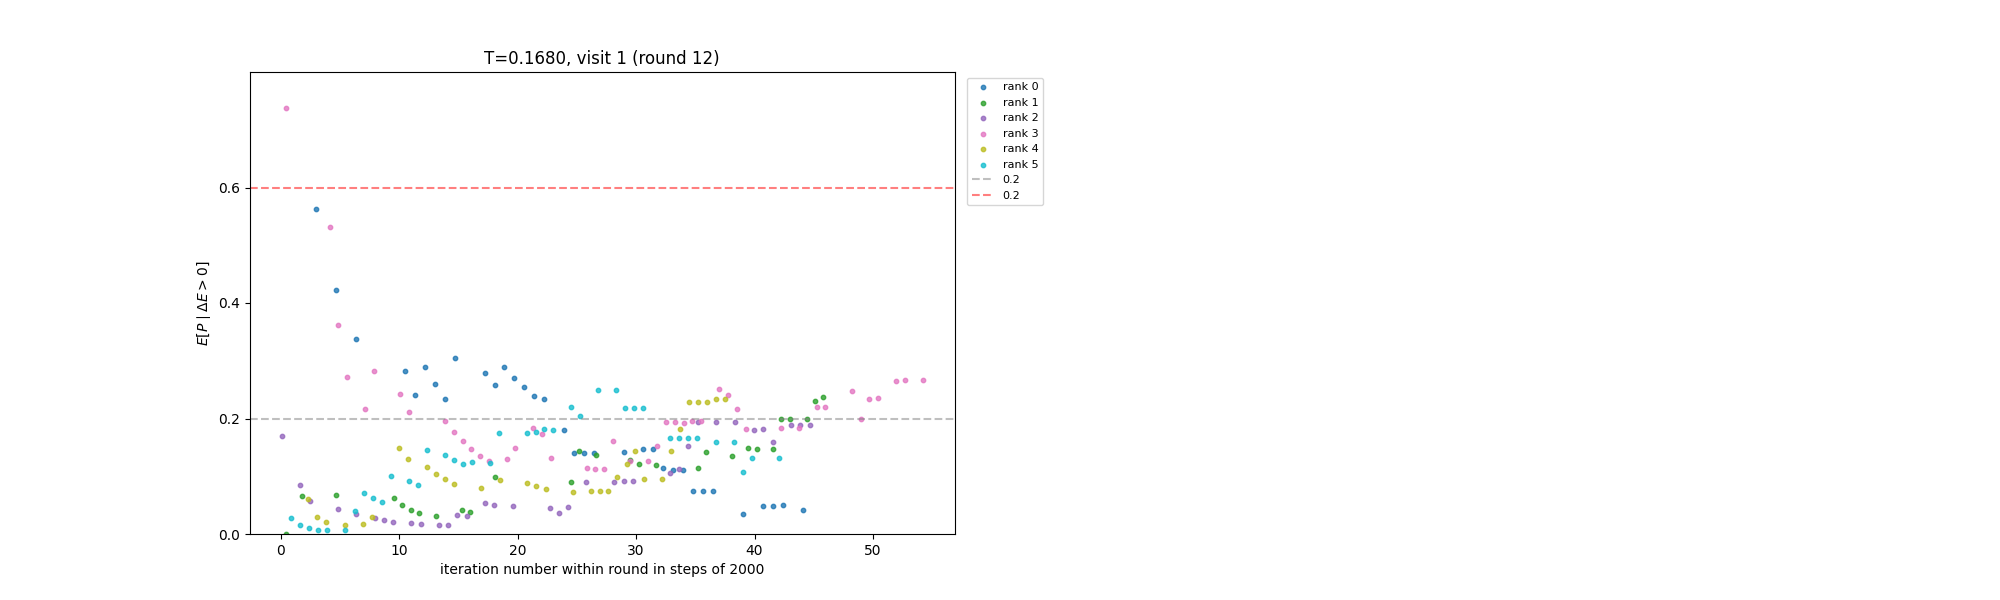

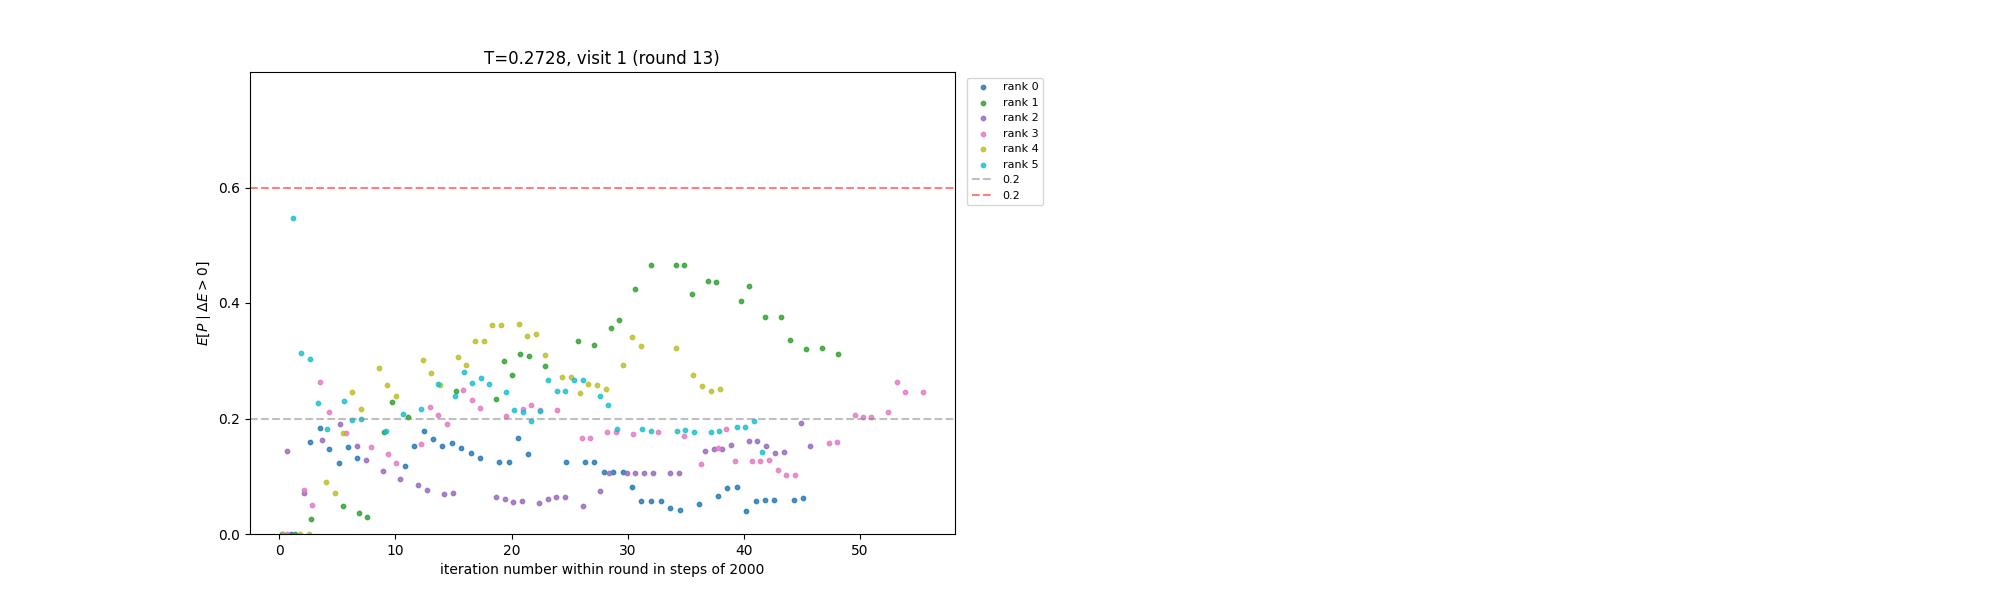

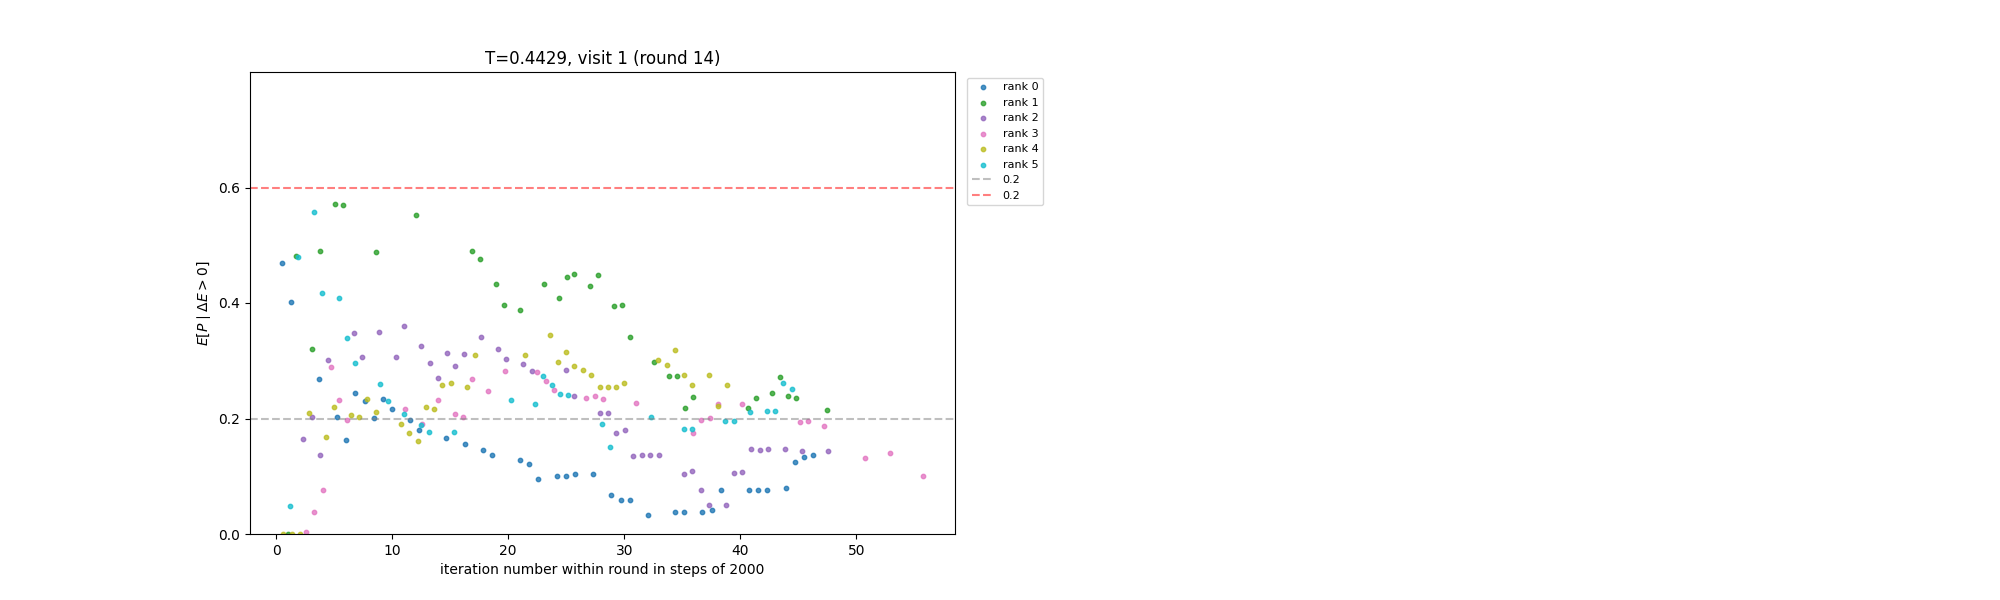

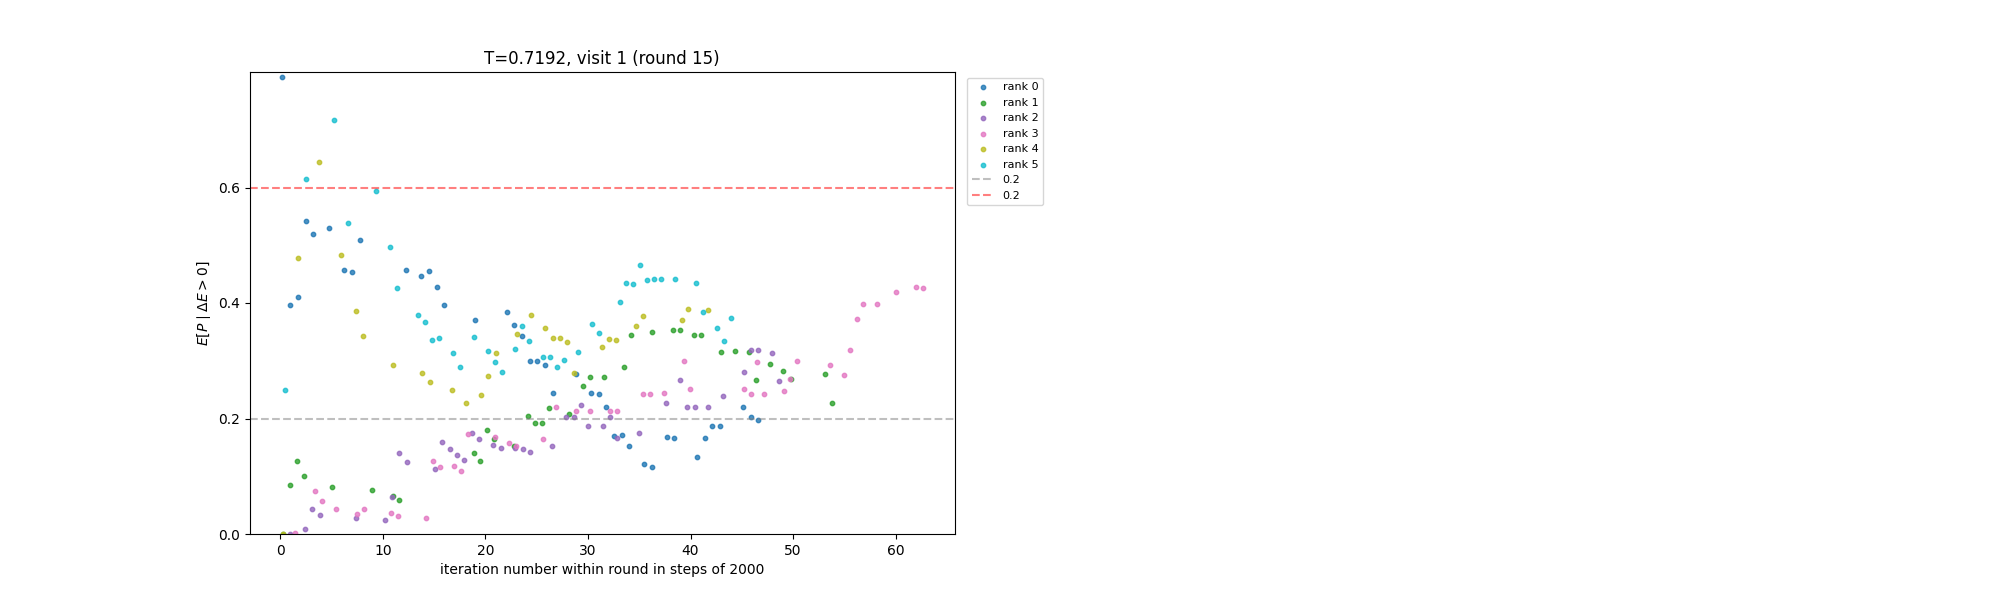

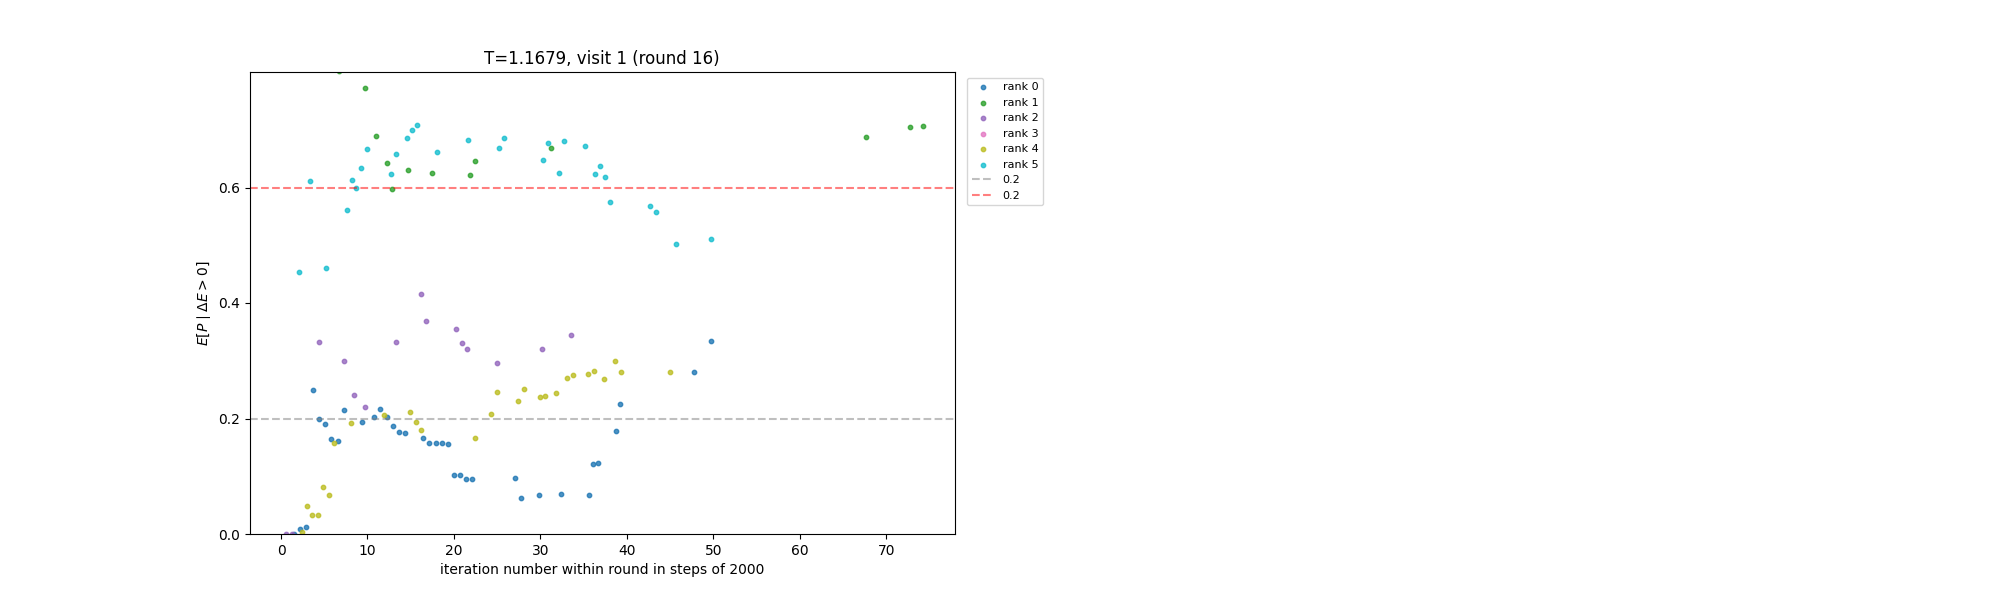

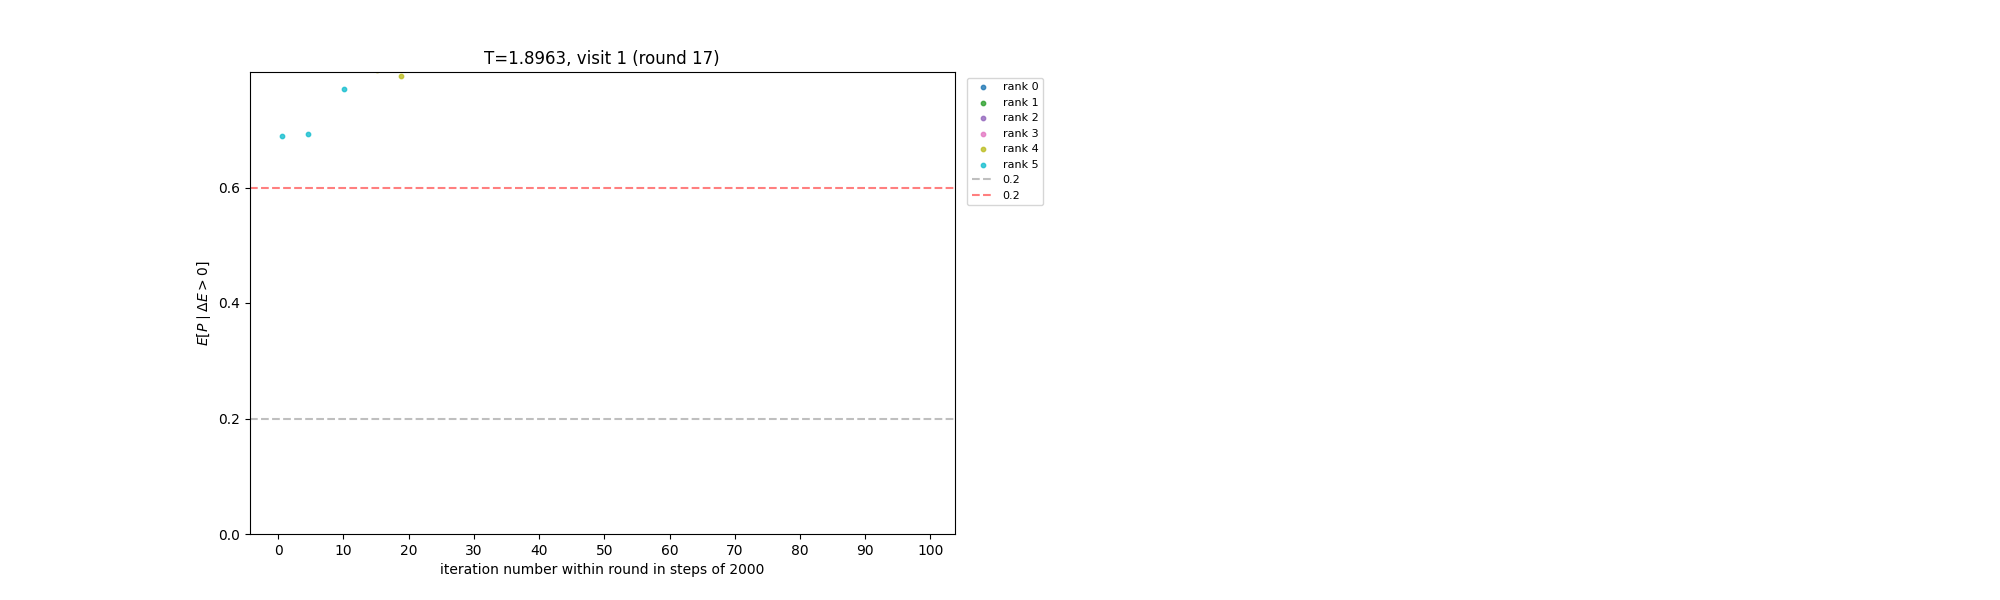

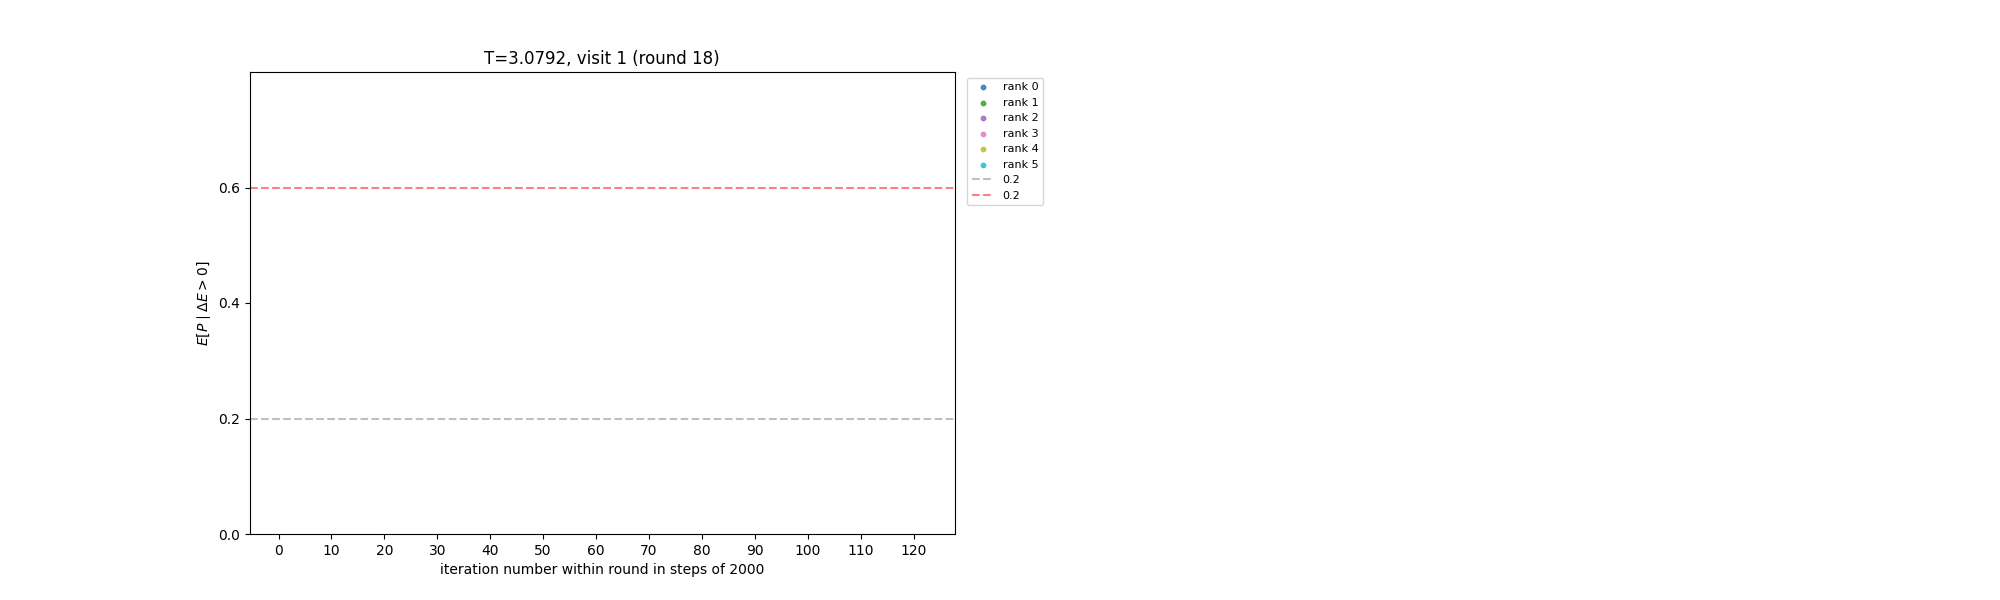

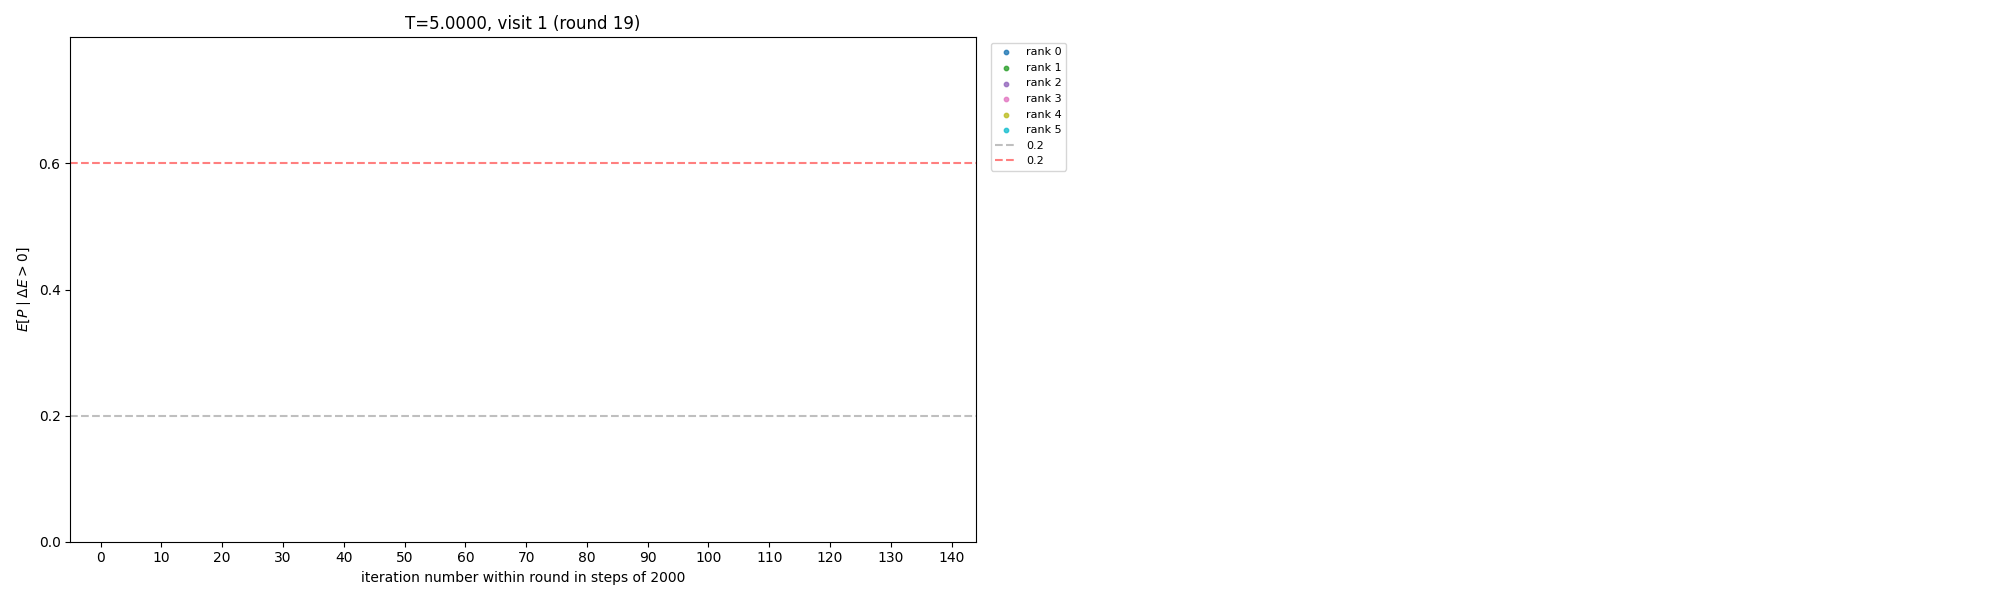

In [16]:
from matplotlib.ticker import MultipleLocator, FuncFormatter
unique_temps = sorted(df_exp_stats_intra_rounds['T'].unique())
cmap = plt.get_cmap('tab10', size)

for T in unique_temps:
    rounds_at_T = sorted(df_exp_stats_intra_rounds[df_exp_stats_intra_rounds['T'] == T]['round_nbr'].unique())
    n_visits = len(rounds_at_T)

    fig = plt.figure(figsize=(20, 6))
    gs = fig.add_gridspec(1, 2)
    axes = [fig.add_subplot(gs[0, i]) for i in range(n_visits)]
    if n_visits == 2:
        axes[1].sharey(axes[0])

    for visit_idx, round_nbr in enumerate(rounds_at_T):
        ax = axes[visit_idx]
        round_data = energy_increasing[energy_increasing['round_nbr'] == round_nbr]
    

        for rank in range(size):
            rank_data = round_data[round_data['rank'] == rank]
            ax.scatter(rank_data['it_no_intra_round'], rank_data['exp(P)'], s=10,
                       color=cmap(rank), label=f'rank {rank}', alpha=0.8)

        ax.ticklabel_format(style='plain', axis='y')
        ax.set_xlabel('iteration number within round in steps of 2000')
        ax.xaxis.set_major_locator(MultipleLocator(20000))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/2000)}'))
        ax.set_ylabel(r'$E[P \mid \Delta E>0]$')
        ax.set_ylim(0, 0.8)
        ax.set_yticks([0, 0.2, 0.4, 0.6])
        ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.5, label='0.2')
        ax.axhline(y=0.6, color='red', linestyle='--', alpha=0.5, label='0.2')
        ax.set_title(f'T={T:.4f}, visit {visit_idx+1} (round {round_nbr})')
        if visit_idx == n_visits - 1:
              ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()

## Temperature suggestion for the average and median energy increasing deformation

In [17]:
def return_temp_for_expected_acceptance(deltaE, acceptance_prob):
    return -deltaE/np.log(acceptance_prob)

In [18]:
mean_deltaE = energy_increasing['deltaE'].mean()
median_deltaE = energy_increasing['deltaE'].median()

# forward table: T -> expected acceptance prob, for both statistics
unique_temps = sorted(df_exp_stats_intra_rounds['T'].unique())
acceptance_by_temp = pd.DataFrame({
    'T': unique_temps,
    'expected_P (mean deltaE)': [np.exp(-mean_deltaE / T) for T in unique_temps],
    'expected_P (median deltaE)': [np.exp(-median_deltaE / T) for T in unique_temps],
})
print(f"mean deltaE = {mean_deltaE:.5f}, median deltaE = {median_deltaE:.5f}\n")
print(acceptance_by_temp.to_string(index=False))

# reverse table: target prob -> suggested T, for both statistics
target_probs = [0.1, 0.2, 0.3, 0.4, 0.5]
suggested_temps = pd.DataFrame({
    'target_acceptance_prob': target_probs,
    'suggested_T (mean deltaE)': [return_temp_for_expected_acceptance(mean_deltaE, p) for p in target_probs],
    'suggested_T (median deltaE)': [return_temp_for_expected_acceptance(median_deltaE, p) for p in target_probs],
})
print()
print(suggested_temps.to_string(index=False))

mean deltaE = 3.49399, median deltaE = 0.97698

       T  expected_P (mean deltaE)  expected_P (median deltaE)
0.000500              0.000000e+00                0.000000e+00
0.000812              0.000000e+00                0.000000e+00
0.001318              0.000000e+00               1.185758e-322
0.002141              0.000000e+00               6.652260e-199
0.003476              0.000000e+00               8.615170e-123
0.005644             1.393513e-269                6.658067e-76
0.009165             2.709455e-166                5.065644e-47
0.014882             1.087369e-102                3.084944e-29
0.024165              1.606080e-63                2.764846e-18
0.039238              2.126803e-39                1.536663e-11
0.063714              1.527013e-24                2.190785e-07
0.103457              2.151880e-15                7.921510e-05
0.167991              9.273390e-10                2.980487e-03
0.272780              2.736481e-06                2.783204e-02
0.44293

In [19]:
conn.close()